In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install cartopy airportsdata
import networkx as nx
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import airportsdata
import numpy as np
from copy import deepcopy
from typing import List
from tabulate import tabulate



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.8/934.8 kB 17.7 MB/s eta 0:00:00


In [ ]:
url = "https://raw.githubusercontent.com/ulfadwyh002/Data-Skripsi-Airport-Dataset/main/DATA_2_BOBOT%20NORM.xlsx"
data = pd.read_excel(url)

data

,Bandara1,Bandara2,Route,Airlines_list,Weight,Weight_norm
0,AAP,BTH,AAP - BTH,"['GA', 'QG']",2,0.649476
1,AAP,BTJ,AAP - BTJ,['ID'],1,0.324738
2,AAP,CGK,AAP - CGK,"['GA', 'QG', 'ID']",3,0.974214
3,AAP,DPS,AAP - DPS,"['GA', 'QG', 'IU']",3,0.974214
4,AAP,HLP,AAP - HLP,['QG'],1,0.324738
...,...,...,...,...,...,...
398,TNJ,UPG,TNJ - UPG,"['GA', 'ID']",2,0.649476
399,TNJ,YIA,TNJ - YIA,['GA'],1,0.324738
400,TRK,UPG,TRK - UPG,"['JT', 'ID', 'IU']",3,0.974214
401,TRK,YIA,TRK - YIA,"['ID', 'IU']",2,0.649476


In [ ]:
data.columns

Index(['Bandara1', 'Bandara2', 'Route', 'Airlines_list', 'Weight',
       'Weight_norm'],
      dtype='object')

# Value Bobot

In [ ]:
# Hitung frekuensi tiap bobot [1,2,3,4,5,6,7,8,9]
data['Weight'].value_counts().sort_index()


,count
Weight,
1,94
2,93
3,74
4,58
5,40
6,19
7,12
8,8
9,5


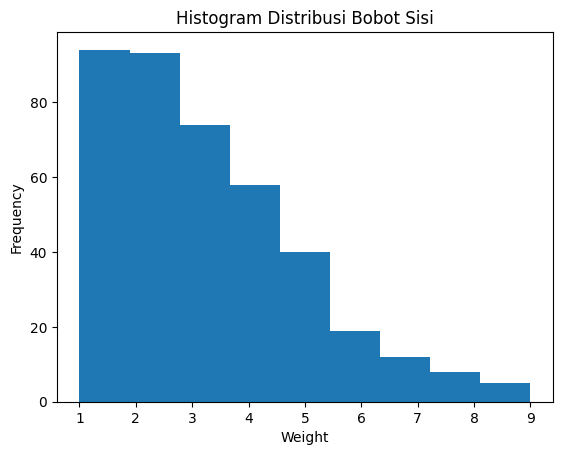

In [ ]:
import matplotlib.pyplot as plt

# Ambil kolom Weight
weights = data['Weight']

# Buat histogram
plt.figure()
plt.hist(weights, bins=9)

# Label
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title("Histogram Distribusi Bobot Sisi")

plt.show()


In [ ]:
# Hitung frekuensi tiap bobot [1,2,3,4,5,6,7,8,9]
data['Weight_norm'].value_counts().sort_index()


,count
Weight_norm,
0.324738,94
0.649476,93
0.974214,74
1.298952,58
1.623691,40
1.948429,19
2.273167,12
2.597905,8
2.922643,5


In [ ]:
data

,Bandara1,Bandara2,Route,Airlines_list,Weight,Weight_norm
0,AAP,BTH,AAP - BTH,"['GA', 'QG']",2,0.649476
1,AAP,BTJ,AAP - BTJ,['ID'],1,0.324738
2,AAP,CGK,AAP - CGK,"['GA', 'QG', 'ID']",3,0.974214
3,AAP,DPS,AAP - DPS,"['GA', 'QG', 'IU']",3,0.974214
4,AAP,HLP,AAP - HLP,['QG'],1,0.324738
...,...,...,...,...,...,...
398,TNJ,UPG,TNJ - UPG,"['GA', 'ID']",2,0.649476
399,TNJ,YIA,TNJ - YIA,['GA'],1,0.324738
400,TRK,UPG,TRK - UPG,"['JT', 'ID', 'IU']",3,0.974214
401,TRK,YIA,TRK - YIA,"['ID', 'IU']",2,0.649476


# Pemodelan Graf

In [ ]:
df = data.copy()


In [ ]:

G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(
        row['Bandara1'],
        row['Bandara2'],
        Weight=row['Weight_norm']
    )

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

# =========================================================
# 1. SET AGAR NUMPY TIDAK MENYINGKAT ARRAY
# =========================================================
np.set_printoptions(threshold=np.inf, linewidth=200)

# =========================================================
# 2. URUTAN SIMPUL (DIAMBIL DARI GRAPH)
# =========================================================
nodes = list(G.nodes())

# =========================================================
# 3. BUAT PEMETAAN v_i ↔ KODE BANDARA
# =========================================================
node_to_v = {node: f"v{i+1}" for i, node in enumerate(nodes)}
v_to_node = {f"v{i+1}": node for i, node in enumerate(nodes)}

# =========================================================
# 4. TAMPILKAN TABEL PEMETAAN (v_i = bandara)
# =========================================================
mapping_df = pd.DataFrame({
    "Simpul (v_i)": list(v_to_node.keys()),
    "Bandara": list(v_to_node.values())
})

print("\nTabel Pemetaan Simpul:")
print(mapping_df.to_string(index=False))


Tabel Pemetaan Simpul:
Simpul (v_i) Bandara
          v1     AAP
          v2     BTH
          v3     BTJ
          v4     CGK
          v5     DPS
          v6     HLP
          v7     KNO
          v8     LBJ
          v9     LOP
         v10     PDG
         v11     PKU
         v12     PLM
         v13     PNK
         v14     SOC
         v15     SRG
         v16     SUB
         v17     TKG
         v18     TNJ
         v19     YIA
         v20     AMQ
         v21     BDJ
         v22     BPN
         v23     KOE
         v24     MDC
         v25     SOQ
         v26     TJQ
         v27     TRK
         v28     UPG
         v29     DJJ
         v30     DTB
         v31     BIK
         v32     BWX
         v33     MKQ
         v34     PLW
         v35     KJT


# Matriks Ketetanggan

In [ ]:
A = nx.to_numpy_array(
    G,
    nodelist=nodes,
    weight='Weight',
    dtype=float
)

In [ ]:
A_df = pd.DataFrame(
    np.round(A, 4),
    index=[node_to_v[n] for n in nodes],
    columns=[node_to_v[n] for n in nodes]
)

print("\nMatriks Ketetanggaan Berbobot A (versi v_i):")
print(A_df)


Matriks Ketetanggaan Berbobot A (versi v_i):
         v1      v2      v3      v4      v5      v6      v7      v8      v9  \
v1   0.0000  0.6495  0.3247  0.9742  0.9742  0.3247  1.2990  0.3247  1.2990   
v2   0.6495  0.0000  0.3247  1.9484  1.6237  0.0000  0.9742  0.6495  1.6237   
v3   0.3247  0.3247  0.0000  1.9484  0.9742  0.0000  0.9742  0.3247  0.9742   
v4   0.9742  1.9484  1.9484  0.0000  2.9226  0.0000  2.9226  1.2990  2.2732   
v5   0.9742  1.6237  0.9742  2.9226  0.0000  0.6495  2.2732  0.9742  0.3247   
v6   0.3247  0.0000  0.0000  0.0000  0.6495  0.0000  0.3247  0.3247  0.0000   
v7   1.2990  0.9742  0.9742  2.9226  2.2732  0.3247  0.0000  1.9484  2.2732   
v8   0.3247  0.6495  0.3247  1.2990  0.9742  0.3247  1.9484  0.0000  0.0000   
v9   1.2990  1.6237  0.9742  2.2732  0.3247  0.0000  2.2732  0.0000  0.0000   
v10  0.3247  0.6495  0.6495  2.5979  2.5979  0.3247  0.9742  0.3247  1.2990   
v11  0.9742  0.9742  0.6495  2.9226  2.9226  0.3247  1.6237  0.3247  2.2732   
v12  0

In [ ]:
# Simpan matriks ketetanggaan berbobot ke CSV
A_df.to_csv("matriks_ketetanggaan_berbobot.csv")

print("File CSV berhasil disimpan.")


File CSV berhasil disimpan.


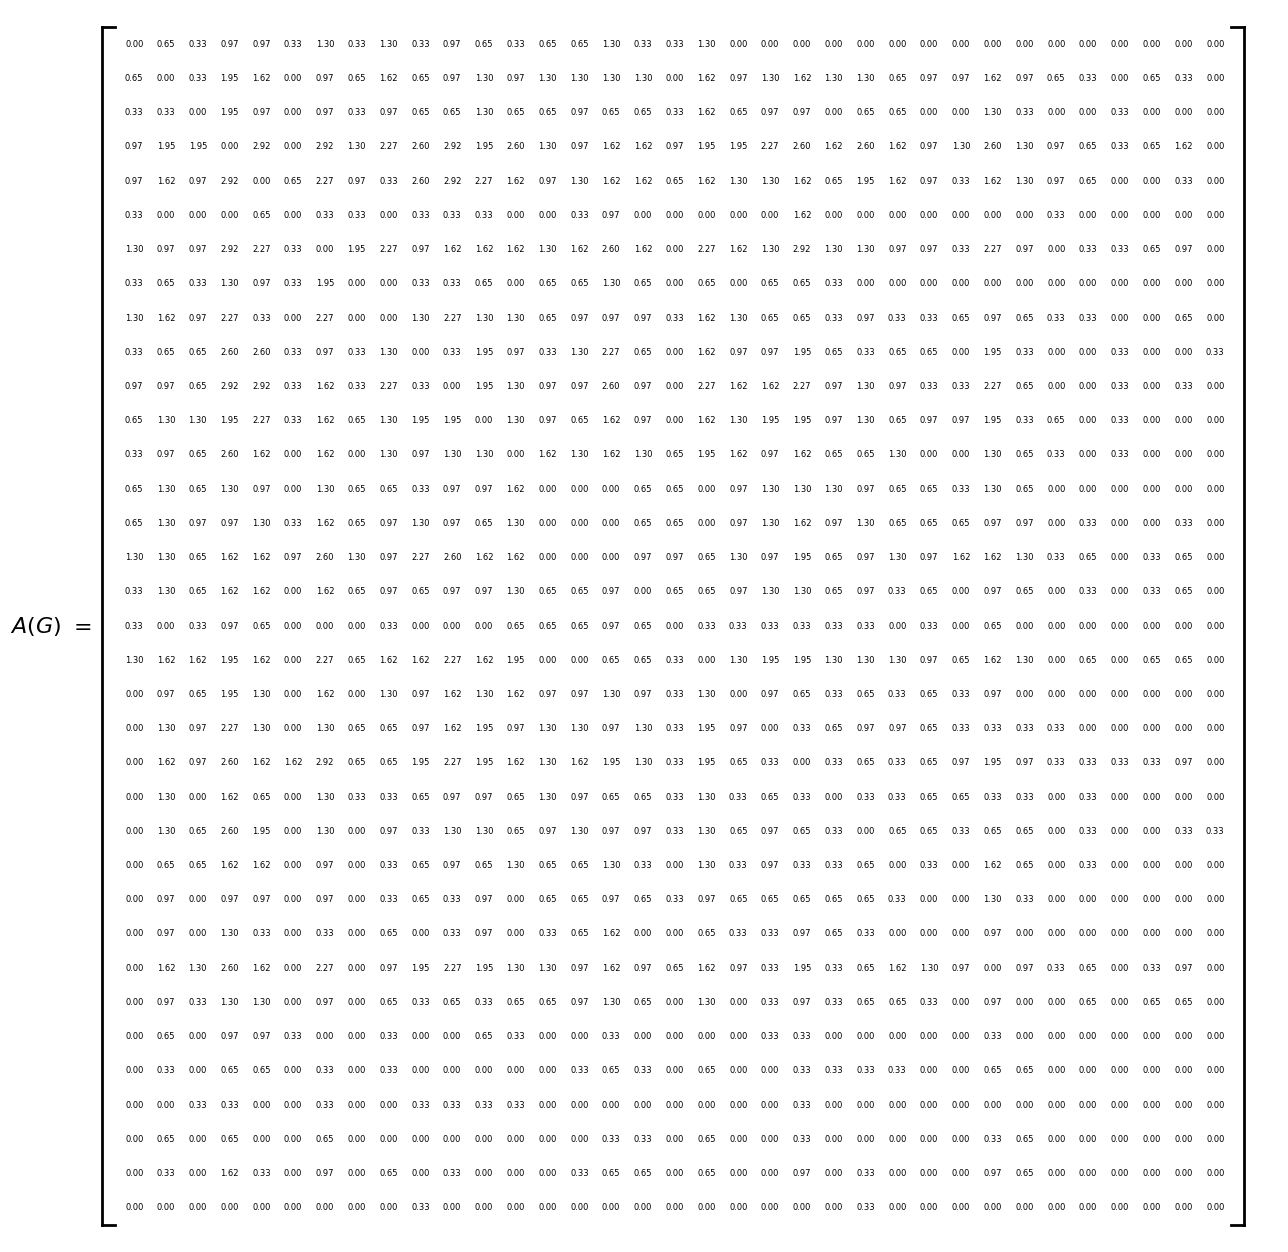

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A_show = np.round(A, 3)
n, m = A_show.shape

fig, ax = plt.subplots(figsize=(16, 16))
ax.axis("off")

# 1️⃣ Isi matriks
for i in range(n):
    for j in range(m):
        ax.text(
            j, n - i - 1,
            f"{A_show[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6
        )
# 2️⃣ Notasi A(G) =
y_mid = (n - 1) / 2

ax.text(
    -2.3, y_mid,
    r"$A(G)$",
    fontsize=16,
    va="center",
    ha="right"      # ⬅️ penting
)

ax.text(
    -1.7, y_mid,
    r"$=$",
    fontsize=16,
    va="center",
    ha="center"
)


# 3️⃣ Kurung siku kiri [
xL = -1.0
ax.plot([xL, xL], [-0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xL, xL + 0.4], [n - 0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xL, xL + 0.4], [-0.5, -0.5], color="black", linewidth=2)

# 4️⃣ Kurung siku kanan ]
xR = m - 0.1
ax.plot([xR, xR], [-0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xR - 0.4, xR], [n - 0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xR - 0.4, xR], [-0.5, -0.5], color="black", linewidth=2)

# 5️⃣ Batas tampilan
ax.set_xlim(-3, m + 1)
ax.set_ylim(-1, n)

plt.show()


# Matriks Diagonal Derajat

In [ ]:
# =========================================================
# 2. FUNGSI MATRKS DERAJAT / STRENGTH
# =========================================================
def degree_matrix_from_adj(A: np.ndarray) -> np.ndarray:
    s = A.sum(axis=1)
    D = np.diag(s)
    return D

D = degree_matrix_from_adj(A)

# Tampilkan
D_df = pd.DataFrame(
    np.round(D, 4),
    index=[node_to_v[n] for n in nodes],
    columns=[node_to_v[n] for n in nodes]
)

print("\nMatriks Derajat / Strength Matrix D (versi v_i):")
print(D_df)



Matriks Derajat / Strength Matrix D (versi v_i):
          v1       v2      v3      v4       v5      v6       v7       v8  \
v1   12.9895   0.0000   0.000   0.000   0.0000  0.0000   0.0000   0.0000   
v2    0.0000  32.1491   0.000   0.000   0.0000  0.0000   0.0000   0.0000   
v3    0.0000   0.0000  19.809   0.000   0.0000  0.0000   0.0000   0.0000   
v4    0.0000   0.0000   0.000  55.855   0.0000  0.0000   0.0000   0.0000   
v5    0.0000   0.0000   0.000   0.000  42.5407  0.0000   0.0000   0.0000   
v6    0.0000   0.0000   0.000   0.000   0.0000  5.8453   0.0000   0.0000   
v7    0.0000   0.0000   0.000   0.000   0.0000  0.0000  44.4891   0.0000   
v8    0.0000   0.0000   0.000   0.000   0.0000  0.0000   0.0000  12.6648   
v9    0.0000   0.0000   0.000   0.000   0.0000  0.0000   0.0000   0.0000   
v10   0.0000   0.0000   0.000   0.000   0.0000  0.0000   0.0000   0.0000   
v11   0.0000   0.0000   0.000   0.000   0.0000  0.0000   0.0000   0.0000   
v12   0.0000   0.0000   0.000   0.000 

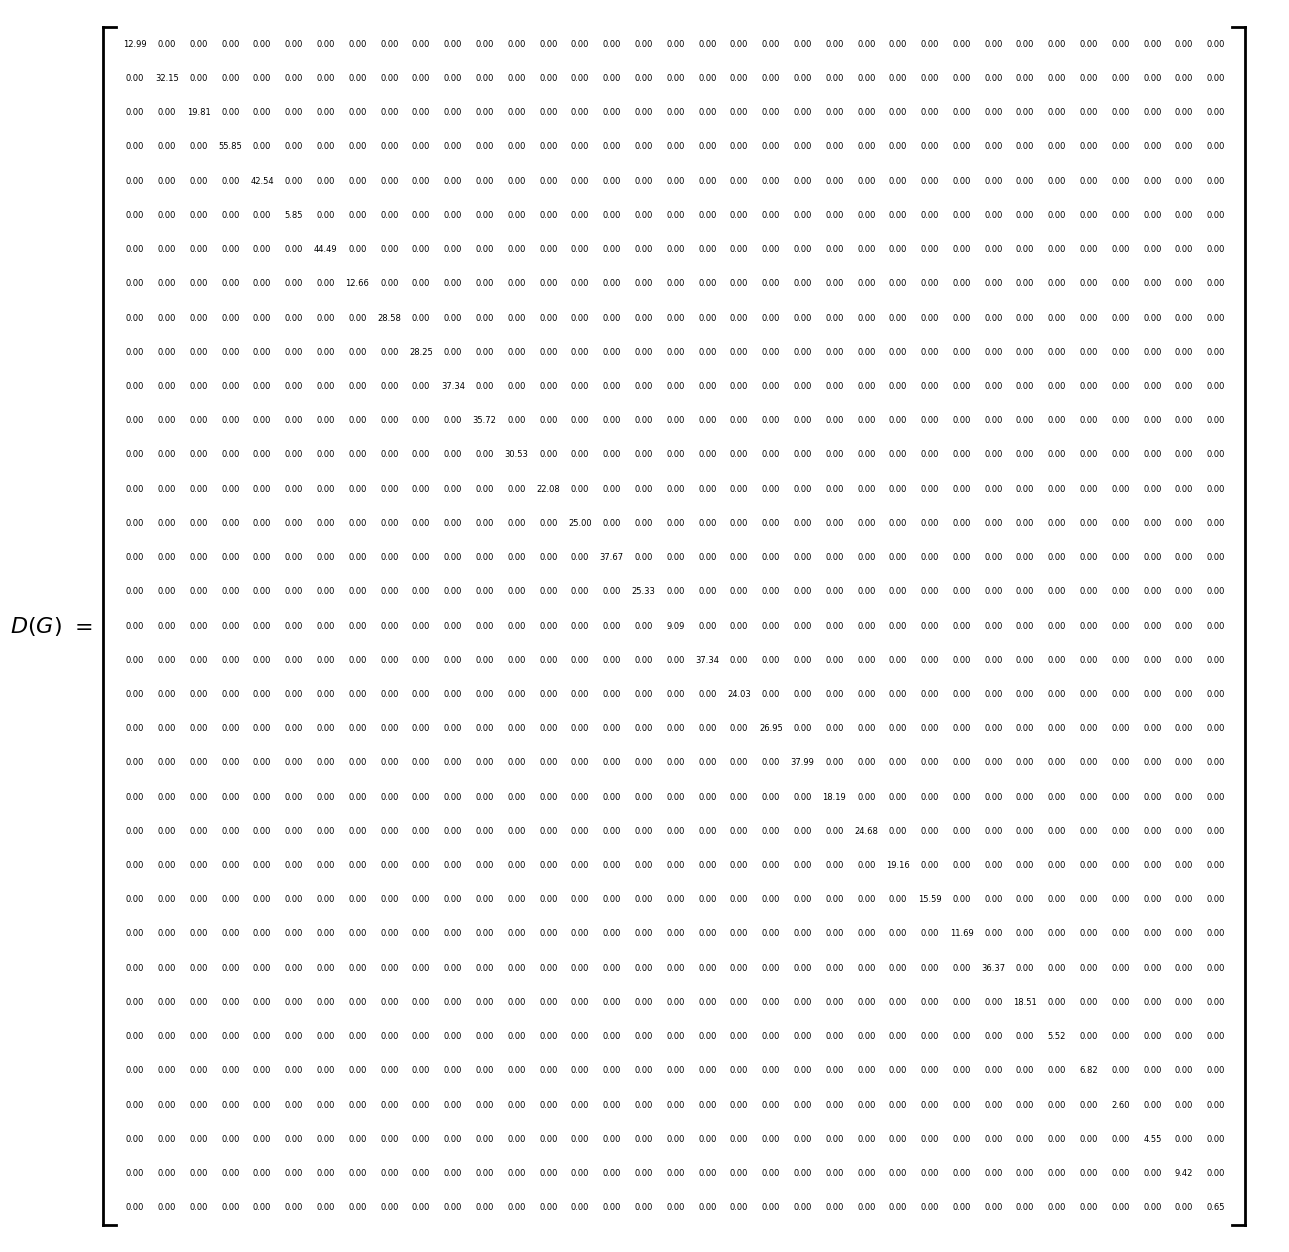

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gunakan matriks D
D_show = np.round(D, 2)
n, m = D_show.shape

fig, ax = plt.subplots(figsize=(16, 16))
ax.axis("off")

# 1️⃣ Isi matriks D
for i in range(n):
    for j in range(m):
        ax.text(
            j, n - i - 1,
            f"{D_show[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6
        )

# 2️⃣ Notasi D(G) =
y_mid = (n - 1) / 2
ax.text(-2.3, y_mid, r"$D(G)$", fontsize=16, va="center", ha="right")
ax.text(-1.7, y_mid, r"$=$", fontsize=16, va="center", ha="center")

# 3️⃣ Kurung siku kiri [
xL = -1.0
ax.plot([xL, xL], [-0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xL, xL + 0.4], [n - 0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xL, xL + 0.4], [-0.5, -0.5], color="black", linewidth=2)

# 4️⃣ Kurung siku kanan ]
xR = m - 0.1
ax.plot([xR, xR], [-0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xR - 0.4, xR], [n - 0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xR - 0.4, xR], [-0.5, -0.5], color="black", linewidth=2)

# 5️⃣ Batas tampilan
ax.set_xlim(-3, m + 1)
ax.set_ylim(-1, n)

plt.show()


In [ ]:
def neighbors_and_weights(A, nodes):
    """
    Menampilkan tetangga setiap simpul dan bobot sisinya
    berdasarkan matriks ketetanggaan berbobot A
    """
    n = A.shape[0]

    for i in range(n):
        vi = nodes[i]
        neighbors = []

        for j in range(n):
            if A[i, j] != 0:
                neighbors.append((nodes[j], A[i, j]))

        print(f"Simpul {vi} bertetangga dengan:")
        if neighbors:
            for vj, w in neighbors:
                print(f"  - {vj} dengan bobot {w:.2f}")
        else:
            print("  - Tidak memiliki tetangga")
        print()


## Pembuktian s1, s2,...,s35.

In [ ]:
neighbors_and_weights(A, nodes)


Simpul AAP bertetangga dengan:
  - BTH dengan bobot 0.65
  - BTJ dengan bobot 0.32
  - CGK dengan bobot 0.97
  - DPS dengan bobot 0.97
  - HLP dengan bobot 0.32
  - KNO dengan bobot 1.30
  - LBJ dengan bobot 0.32
  - LOP dengan bobot 1.30
  - PDG dengan bobot 0.32
  - PKU dengan bobot 0.97
  - PLM dengan bobot 0.65
  - PNK dengan bobot 0.32
  - SOC dengan bobot 0.65
  - SRG dengan bobot 0.65
  - SUB dengan bobot 1.30
  - TKG dengan bobot 0.32
  - TNJ dengan bobot 0.32
  - YIA dengan bobot 1.30

Simpul BTH bertetangga dengan:
  - AAP dengan bobot 0.65
  - BTJ dengan bobot 0.32
  - CGK dengan bobot 1.95
  - DPS dengan bobot 1.62
  - KNO dengan bobot 0.97
  - LBJ dengan bobot 0.65
  - LOP dengan bobot 1.62
  - PDG dengan bobot 0.65
  - PKU dengan bobot 0.97
  - PLM dengan bobot 1.30
  - PNK dengan bobot 0.97
  - SOC dengan bobot 1.30
  - SRG dengan bobot 1.30
  - SUB dengan bobot 1.30
  - TKG dengan bobot 1.30
  - YIA dengan bobot 1.62
  - AMQ dengan bobot 0.97
  - BDJ dengan bobot 1.30
 

In [ ]:
# Total Bobot tiap Simpul
strength = A.sum(axis=1)
df_strength = pd.DataFrame({
    "Simpul (v_i)": [node_to_v[n] for n in nodes],
    "Total Bobot (Strength)": np.round(strength, 6)
})

print("\nTotal Bobot Tiap Simpul (versi v_i):")
print(df_strength.to_string(index=False))



Total Bobot Tiap Simpul (versi v_i):
Simpul (v_i)  Total Bobot (Strength)
          v1               12.989525
          v2               32.149073
          v3               19.809025
          v4               55.854956
          v5               42.540693
          v6                5.845286
          v7               44.489122
          v8               12.664786
          v9               28.576954
         v10               28.252216
         v11               37.344883
         v12               35.721193
         v13               30.525383
         v14               22.082192
         v15               25.004835
         v16               37.669621
         v17               25.329573
         v18                9.092667
         v19               37.344883
         v20               24.030620
         v21               26.953263
         v22               37.994359
         v23               18.185334
         v24               24.680097
         v25               19.159549


# Matriks laplacian

In [ ]:
# 6. HITUNG LAPACIAN BERBOBOT L = D - A
# =========================================================
L = D - A

# =========================================================
# 7. TAMPILKAN LAPACIAN DENGAN LABEL v_i
# =========================================================
L_df = pd.DataFrame(
    np.round(L, 4),
    index=[node_to_v[n] for n in nodes],
    columns=[node_to_v[n] for n in nodes]
)

print("\nMatriks Laplacian Berbobot L (versi v_i):")
print(L_df)


Matriks Laplacian Berbobot L (versi v_i):
          v1       v2       v3       v4       v5      v6       v7       v8  \
v1   12.9895  -0.6495  -0.3247  -0.9742  -0.9742 -0.3247  -1.2990  -0.3247   
v2   -0.6495  32.1491  -0.3247  -1.9484  -1.6237  0.0000  -0.9742  -0.6495   
v3   -0.3247  -0.3247  19.8090  -1.9484  -0.9742  0.0000  -0.9742  -0.3247   
v4   -0.9742  -1.9484  -1.9484  55.8550  -2.9226  0.0000  -2.9226  -1.2990   
v5   -0.9742  -1.6237  -0.9742  -2.9226  42.5407 -0.6495  -2.2732  -0.9742   
v6   -0.3247   0.0000   0.0000   0.0000  -0.6495  5.8453  -0.3247  -0.3247   
v7   -1.2990  -0.9742  -0.9742  -2.9226  -2.2732 -0.3247  44.4891  -1.9484   
v8   -0.3247  -0.6495  -0.3247  -1.2990  -0.9742 -0.3247  -1.9484  12.6648   
v9   -1.2990  -1.6237  -0.9742  -2.2732  -0.3247  0.0000  -2.2732   0.0000   
v10  -0.3247  -0.6495  -0.6495  -2.5979  -2.5979 -0.3247  -0.9742  -0.3247   
v11  -0.9742  -0.9742  -0.6495  -2.9226  -2.9226 -0.3247  -1.6237  -0.3247   
v12  -0.6495  -1.2990

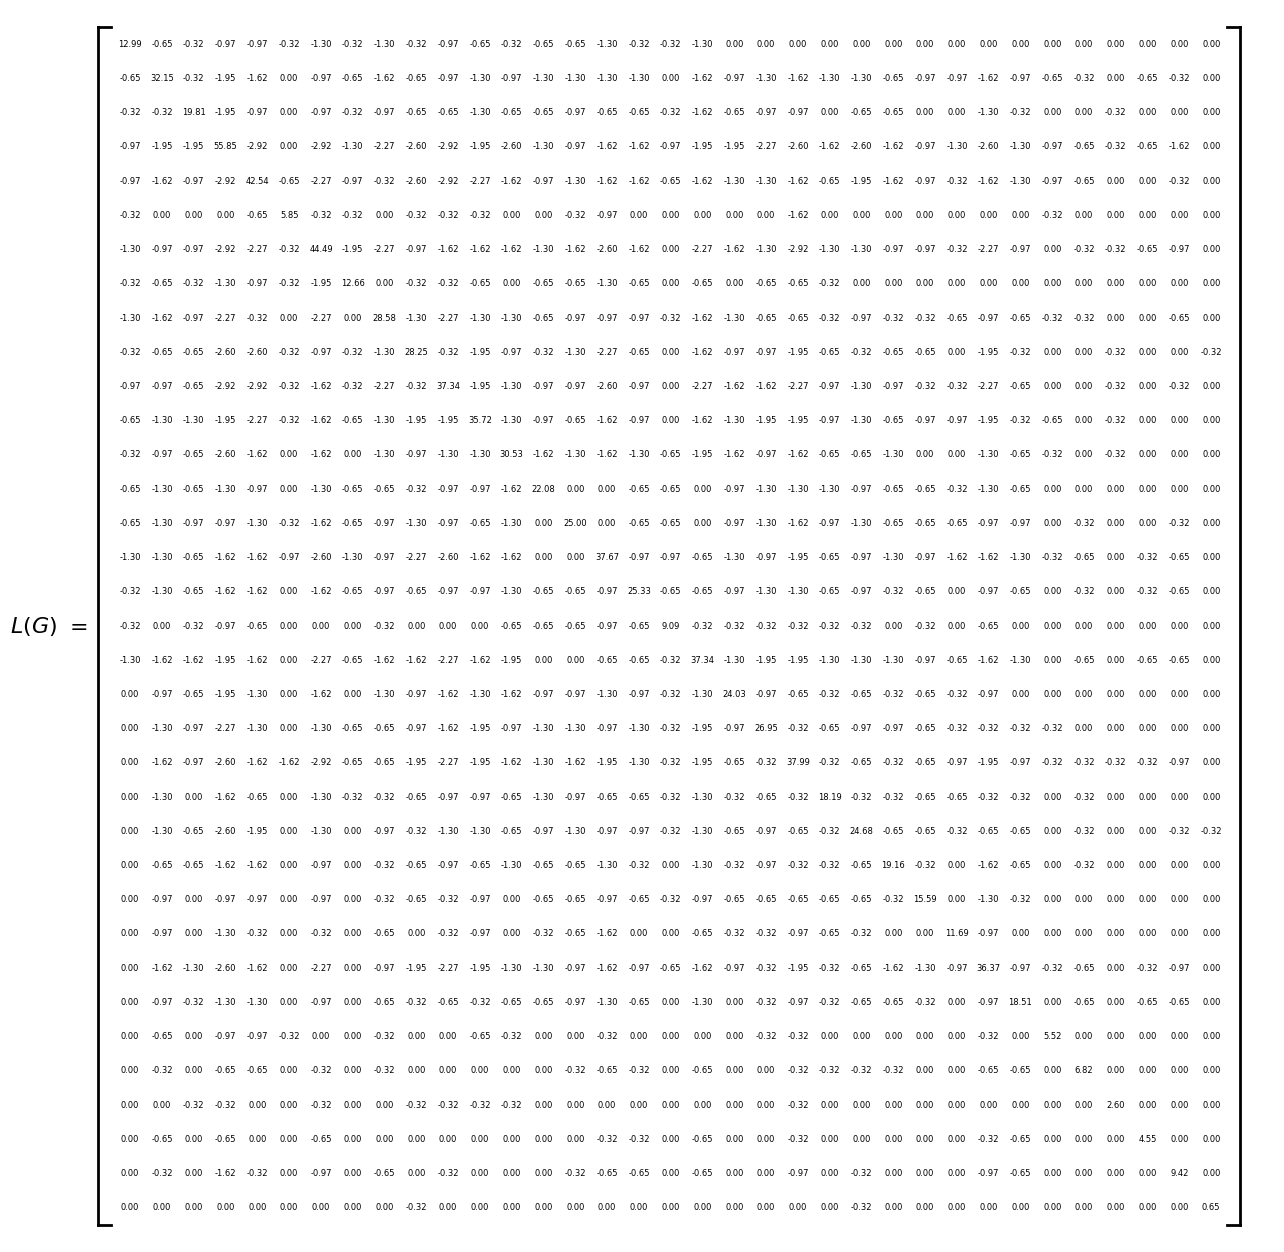

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Gunakan matriks D
L_show = np.round(L, 2)
n, m = L_show.shape

fig, ax = plt.subplots(figsize=(16, 16))
ax.axis("off")

# 1️⃣ Isi matriks L
for i in range(n):
    for j in range(m):
        ax.text(
            j, n - i - 1,
            f"{L_show[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=6
        )

# 2️⃣ Notasi D(G) =
y_mid = (n - 1) / 2
ax.text(-2.3, y_mid, r"$L(G)$", fontsize=16, va="center", ha="right")
ax.text(-1.7, y_mid, r"$=$", fontsize=16, va="center", ha="center")

# 3️⃣ Kurung siku kiri [
xL = -1.0
ax.plot([xL, xL], [-0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xL, xL + 0.4], [n - 0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xL, xL + 0.4], [-0.5, -0.5], color="black", linewidth=2)

# 4️⃣ Kurung siku kanan ]
xR = m - 0.1
ax.plot([xR, xR], [-0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xR - 0.4, xR], [n - 0.5, n - 0.5], color="black", linewidth=2)
ax.plot([xR - 0.4, xR], [-0.5, -0.5], color="black", linewidth=2)

# 5️⃣ Batas tampilan
ax.set_xlim(-3, m + 1)
ax.set_ylim(-1, n)

plt.show()


# energi laplacian

In [ ]:
# =========================================================
# SPEKTRUM LAPLACIAN + PENANGANAN ERROR NUMERIK
# =========================================================

# hitung nilai eigen (khusus matriks simetris)
eigvals = np.linalg.eigvalsh(L)

# urutkan
eigvals = np.sort(eigvals)

# perbaiki error numerik: nilai ~0 dianggap 0
eigvals[np.isclose(eigvals, 0, atol=1e-10)] = 0.0

print("Spektrum Nilai Eigen Laplacian L(G):\n")
for i, val in enumerate(eigvals, start=1):
    print(f"λ{i} = {val}")


Spektrum Nilai Eigen Laplacian L(G):

λ1 = 0.0
λ2 = 0.6604285540788137
λ3 = 2.6450665682814742
λ4 = 4.578055806985286
λ5 = 5.517110103566185
λ6 = 5.96237797062434
λ7 = 6.978329405019453
λ8 = 9.122677434380622
λ9 = 9.731979447543658
λ10 = 11.769321477333449
λ11 = 13.012120223722643
λ12 = 13.234879668327334
λ13 = 16.243457464965395
λ14 = 18.39599804256503
λ15 = 19.049158995743625
λ16 = 19.90795084930017
λ17 = 21.367380982405887
λ18 = 22.710059870808205
λ19 = 24.869983554339665
λ20 = 25.806427911606256
λ21 = 26.136948520775842
λ22 = 27.042461093522412
λ23 = 27.900467505752793
λ24 = 29.351147022645982
λ25 = 31.207190672440056
λ26 = 32.80614490820743
λ27 = 34.41849162251428
λ28 = 37.820882602931306
λ29 = 38.28872998585548
λ30 = 38.72056329773766
λ31 = 40.155441335394464
λ32 = 41.03870118106137
λ33 = 44.29686140692178
λ34 = 47.101067065668744
λ35 = 58.15213744697293


## Spektrum menurun



In [ ]:
# =========================================================
# SPEKTRUM LAPLACIAN (SESUSAI NOTASI TEORI)
# =========================================================

# hitung nilai eigen (matriks simetris)
eigvals = np.linalg.eigvalsh(L)

# perbaiki error numerik
eigvals[np.isclose(eigvals, 0, atol=1e-10)] = 0.0

# urutkan MENURUN (sesuai μ₁ ≥ μ₂ ≥ ... ≥ μₙ)
eigvals = eigvals[::-1]

print("Spektrum Nilai Eigen Laplacian L(G):\n")
for i, val in enumerate(eigvals, start=1):
    print(f"μ_{i} = {val}")


Spektrum Nilai Eigen Laplacian L(G):

μ_1 = 58.15213744697293
μ_2 = 47.101067065668744
μ_3 = 44.29686140692178
μ_4 = 41.03870118106137
μ_5 = 40.155441335394464
μ_6 = 38.72056329773766
μ_7 = 38.28872998585548
μ_8 = 37.820882602931306
μ_9 = 34.41849162251428
μ_10 = 32.80614490820743
μ_11 = 31.207190672440056
μ_12 = 29.351147022645982
μ_13 = 27.900467505752793
μ_14 = 27.042461093522412
μ_15 = 26.136948520775842
μ_16 = 25.806427911606256
μ_17 = 24.869983554339665
μ_18 = 22.710059870808205
μ_19 = 21.367380982405887
μ_20 = 19.90795084930017
μ_21 = 19.049158995743625
μ_22 = 18.39599804256503
μ_23 = 16.243457464965395
μ_24 = 13.234879668327334
μ_25 = 13.012120223722643
μ_26 = 11.769321477333449
μ_27 = 9.731979447543658
μ_28 = 9.122677434380622
μ_29 = 6.978329405019453
μ_30 = 5.96237797062434
μ_31 = 5.517110103566185
μ_32 = 4.578055806985286
μ_33 = 2.6450665682814742
μ_34 = 0.6604285540788137
μ_35 = 0.0


## Total nilai eigen (trace)

# WLEC

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx

# =========================================================
# 0. ASUMSI: G sudah ada sebagai networkx Graph
# =========================================================

# =========================================================
# 1. SET AGAR NUMPY TIDAK MENYINGKAT ARRAY
# =========================================================
np.set_printoptions(threshold=np.inf, linewidth=200)

# =========================================================
# 2. URUTAN SIMPUL
# =========================================================
nodes = list(G.nodes())

# =========================================================
# 3. BUAT PEMETAAN v_i ↔ KODE BANDARA
# =========================================================
node_to_v = {node: f"v{i+1}" for i, node in enumerate(nodes)}
v_to_node = {f"v{i+1}": node for i, node in enumerate(nodes)}

# =========================================================
# 4. TAMPILKAN TABEL PEMETAAN
# =========================================================
mapping_df = pd.DataFrame({
    "Simpul (v_i)": list(v_to_node.keys()),
    "Bandara": list(v_to_node.values())
})

print("\nTabel Pemetaan Simpul:")
print(mapping_df.to_string(index=False))

# =========================================================
# 5. KONVERSI GRAPH KE MATRKS ADJACENCY BERBOBOT
# =========================================================
A = nx.to_numpy_array(G, nodelist=nodes, weight='Weight', dtype=float)

# =========================================================
# 6. HITUNG DEGREE MATRIX
# =========================================================
def degree_matrix_from_adj(A: np.ndarray) -> np.ndarray:
    """Menghitung matriks derajat D dari adjacency matrix A"""
    s = A.sum(axis=1)
    D = np.diag(s)
    return D

D = degree_matrix_from_adj(A)

# =========================================================
# 7. HITUNG LAPLACIAN BERBOBOT
# =========================================================
L = D - A

# =========================================================
# 8. HITUNG ENERGI LAPLACIAN E_L^k
# =========================================================
k = 3
L_power_k = np.linalg.matrix_power(L, k)
E_Lk_G = float(np.trace(L_power_k))

print(f"\nEnergi Laplacian E_L^{k}(G) = {E_Lk_G:.6f}")

# =========================================================
# HITUNG WLEC SESUAI DEFINISI ENERGI SELISIH
# WLEC(v_i) = E_L^k(G) - E_L^k(G - v_i)
# =========================================================
N = L.shape[0]
wlec = []

for node in nodes:
    # Buat graph tanpa simpul node
    G_minus_node = G.copy()
    G_minus_node.remove_node(node)

    # Adjacency matrix dan Laplacian baru
    A_minus = nx.to_numpy_array(G_minus_node, nodelist=list(G_minus_node.nodes()), weight='Weight', dtype=float)
    D_minus = degree_matrix_from_adj(A_minus)
    L_minus = D_minus - A_minus

    # Energi Laplacian graph tanpa simpul node
    # Jika graph kosong (misal node terakhir), energi = 0
    if L_minus.size == 0:
        E_Lk_minus = 0
    else:
        # Pangkat k
        k = 3
        L_minus_power_k = np.linalg.matrix_power(L_minus, k)
        E_Lk_minus = float(np.trace(L_minus_power_k))

    # WLEC = energi G - energi G tanpa node
    wlec.append(E_Lk_G - E_Lk_minus)

# Buat DataFrame hasil WLEC
wlec_df = pd.DataFrame({
    "Simpul (v_i)": list(v_to_node.keys()),
    "Bandara": list(v_to_node.values()),
    f"WLEC^{k}": wlec
})

# Urutkan dari besar ke kecil
wlec_df_sorted = wlec_df.sort_values(by=f"WLEC^{k}", ascending=False).reset_index(drop=True)

print("\nWLEC tiap simpul (urut dari besar ke kecil):")
print(wlec_df_sorted.to_string(index=False))



Tabel Pemetaan Simpul:
Simpul (v_i) Bandara
          v1     AAP
          v2     BTH
          v3     BTJ
          v4     CGK
          v5     DPS
          v6     HLP
          v7     KNO
          v8     LBJ
          v9     LOP
         v10     PDG
         v11     PKU
         v12     PLM
         v13     PNK
         v14     SOC
         v15     SRG
         v16     SUB
         v17     TKG
         v18     TNJ
         v19     YIA
         v20     AMQ
         v21     BDJ
         v22     BPN
         v23     KOE
         v24     MDC
         v25     SOQ
         v26     TJQ
         v27     TRK
         v28     UPG
         v29     DJJ
         v30     DTB
         v31     BIK
         v32     BWX
         v33     MKQ
         v34     PLW
         v35     KJT

Energi Laplacian E_L^3(G) = 969342.359712

WLEC tiap simpul (urut dari besar ke kecil):
Simpul (v_i) Bandara        WLEC^3
          v4     CGK 335665.901423
          v7     KNO 231954.566411
          v5     DPS 21444

In [ ]:

# Utility: buat adjacency matrix berbobot sesuai urutan node
def adjacency_matrix_weighted(G: nx.Graph, nodelist: List = None) -> np.ndarray:
    if nodelist is None:
        nodelist = list(G.nodes())     # Mengambil daftar node
    A = nx.to_numpy_array(G, nodelist=nodelist, weight='Weight', dtype=float)  # buat matriks adjacency berbobot
    return A

# Utility: buat matriks derajat (degree/strength) diagonal dari adjacency
def degree_matrix_from_adj(A: np.ndarray) -> np.ndarray:
    s = A.sum(axis=1)                  # jumlah bobot per baris = total koneksi node
    D = np.diag(s)                     # ubah menjadi matriks diagonal
    return D

# Utility: bangun Laplacian L = D - A
def weighted_laplacian(A: np.ndarray) -> np.ndarray:
    D = degree_matrix_from_adj(A)      # hitung matriks derajat
    return D - A                       # rumus dasar Laplacian berbobot (L=D-A)

# Utility: hitung trace(L^k) menggunakan numpy (jejak dari matriks berpangkat k)
def trace_power(L: np.ndarray, k: int) -> float:
    Lk = np.linalg.matrix_power(L, k)  # pangkatkan matriks L sebanyak k kali
    return float(np.trace(Lk))         # ambil nilai trace (jumlah elemen diagonal)

# Fungsi utama: hitung Weighted Laplacian Energy Centrality untuk semua node
def weighted_laplacian_energy_centrality(G: nx.Graph, k: int = 3):
    G0 = deepcopy(G)                   # salin graph agar data asli tidak berubah
    nodes = list(G0.nodes())           # ambil daftar semua node
    n = len(nodes)                     # simpan jumlah node

    # Hitung matriks adjacency & Laplacian untuk graph asli
    A = adjacency_matrix_weighted(G0, nodelist=nodes)
    L = weighted_laplacian(A)
    E_Lk_G = trace_power(L, k)         # hitung energi Laplacian berpangkat k => tr(L^k)
    print(f"E_L^{k}(G) = {E_Lk_G:.6f}") # tampilkan nilai energi total graph (6 angka di belakang koma)

    # Loop untuk menghitung LC^k(v) setiap node
    results = []
    for i, v in enumerate(nodes):
        G_minus = G0.copy()            # salin graph
        G_minus.remove_node(v)         # hapus node v untuk lihat dampaknya

        if len(G_minus) == 0:          # jika semua node terhapus
            E_minus = 0.0              # maka energinya nol
        else:
            nodes_minus = list(G_minus.nodes())  # ambil node tersisa
            A_minus = adjacency_matrix_weighted(G_minus, nodelist=nodes_minus)
            L_minus = weighted_laplacian(A_minus)
            E_minus = trace_power(L_minus, k)    # hitung energi setelah node dihapus

        LC_v = E_Lk_G - E_minus        # selisih energi = nilai centrality node v yaitu energi total dikurangi energi setelah simpul dihapus
        results.append({
            "node": v,
            f"E_L{k}_G_minus_v": E_minus,
            f"LC{k}(v)": LC_v
        })

    # Simpan hasil ke DataFrame dan urutkan berdasarkan nilai LC menurun
    df_res = pd.DataFrame(results)
    df_res = df_res.sort_values(by=f"LC{k}(v)", ascending=False).reset_index(drop=True)
    return E_Lk_G, df_res

# Jalankan fungsi dengan k = 3
k = 3
E_L3_G, df_centrality = weighted_laplacian_energy_centrality(G, k=k)

# Tampilkan hasil
print("\nHasil Weighted Laplacian Energy Centrality (k=3):")
print(tabulate(df_centrality, headers='keys', tablefmt='fancy_grid', showindex=True))


E_L^3(G) = 969342.359712

Hasil Weighted Laplacian Energy Centrality (k=3):
╒════╤════════╤══════════════════╤═══════════╕
│    │ node   │   E_L3_G_minus_v │    LC3(v) │
╞════╪════════╪══════════════════╪═══════════╡
│  0 │ CGK    │           633676 │ 335666    │
├────┼────────┼──────────────────┼───────────┤
│  1 │ KNO    │           737388 │ 231955    │
├────┼────────┼──────────────────┼───────────┤
│  2 │ DPS    │           754900 │ 214442    │
├────┼────────┼──────────────────┼───────────┤
│  3 │ PKU    │           778236 │ 191107    │
├────┼────────┼──────────────────┼───────────┤
│  4 │ BPN    │           784411 │ 184932    │
├────┼────────┼──────────────────┼───────────┤
│  5 │ UPG    │           797389 │ 171954    │
├────┼────────┼──────────────────┼───────────┤
│  6 │ YIA    │           799680 │ 169662    │
├────┼────────┼──────────────────┼───────────┤
│  7 │ SUB    │           802840 │ 166503    │
├────┼────────┼──────────────────┼───────────┤
│  8 │ PLM    │           80508

# Topologi Jaringan

In [ ]:

# 2. Hitung N awal (jumlah node)
N_initial = len(G)  # Menghitung jumlah node awal (bandara)

# <k>: Rata-rata degree/titik (unweighted)
def average_degree(G):  # Definisi fungsi untuk menghitung rata-rata derajat node (unweighted, tanpa bobot)
    degrees = [d for n, d in G.degree()]  # Mengumpulkan derajat (jumlah koneksi) setiap node
    return np.mean(degrees)  # Mengembalikan rata-rata derajat menggunakan NumPy

# C: Clustering coefficient rata-rata (unweighted)
def average_clustering(G):  # Definisi fungsi untuk menghitung rata-rata koefisien clustering (seberapa saling terhubung tetangga node)
    return np.mean(list(nx.clustering(G).values()))  # Menggunakan NetworkX untuk hitung clustering per node, lalu rata-rata

# Lw: Weighted average shortest path length (cost=1/weight, pada biggest CC saja jika tidak terhubung)
def average_weighted_path_length(G):  # Definisi fungsi untuk rata-rata panjang jalur terpendek berbobot
    if len(G) <= 1: return 0  # Jika graf <=1 node, panjang 0
    H = G.copy()  # Salin graf
    for u, v, data in H.edges(data=True):  # Loop setiap edge untuk set cost
        w = data.get("Weight_norm", 1)  # Ambil Weight
        data["cost"] = 1 / w if w > 0 else 1e9  # Set cost = 1/Weight => semakin besar bobot maka semakin baik
    if not nx.is_connected(H):  # Jika graf tidak terhubung
        largest_cc = max(nx.connected_components(H), key=len)  # Cari komponen terbesar
        H = H.subgraph(largest_cc).copy()  # Buat subgraph hanya komponen terbesar
    return nx.average_shortest_path_length(H, weight="cost")  # Hitung rata-rata panjang jalur terpendek berbobot pada subgraph

def largest_connected_component_ratio(G, N_initial):  # Fungsi untuk rasio ukuran komponen terbesar vs N awal
    if len(G) == 0: return 0  # Jika graf kosong, kembalikan 0 untuk hindari error
    largest_cc = max(nx.connected_components(G), key=len)  # Cari komponen terbesar berdasarkan jumlah node
    return len(largest_cc) / N_initial  # Hitung rasio ukuran komponen terbesar terhadap N awal

def weighted_efficiency(G):  # Fungsi untuk efisiensi global berbobot (rata-rata 1/distance)
    if len(G) <= 1: return 0  # Jika graf kecil, efisiensi 0
    H = G.copy()  # Salin graf untuk modifikasi
    for u, v, data in H.edges(data=True):  # Loop setiap edge untuk ubah bobot menjadi cost
        w = data.get("Weight_norm", 1)  # Ambil bobot Weight
        data["cost"] = 1 / w if w > 0 else 1e9  # Set cost = 1/Weight (kebalikan bobot)
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="cost"))  # Hitung panjang jalur terpendek berbobot untuk semua pasangan
    n = len(G)  # Jumlah node
    eff_sum = 0  # Inisialisasi sum efisiensi
    for u in G.nodes():  # Loop node u
        for v in G.nodes():  # Loop node v
            if u != v:  # Hindari pasangan sama
                try:  # Coba ambil distance
                    d = path_lengths[u][v]  # Ambil panjang jalur u-v
                    if d > 0:  # Jika terhubung
                        eff_sum += 1 / d  # Tambahkan 1/d ke sum
                except KeyError:  # Jika tidak terhubung, lewati
                    pass
    return eff_sum / (n * (n - 1))  # Kembalikan rata-rata efisiensi

# Hitung metrik-metrik global jaringan
network_metrics = {
    "<k>": average_degree(G),
    "C": average_clustering(G),
    "Lw": average_weighted_path_length(G),
    "S": largest_connected_component_ratio(G, N_initial),
    "Ew": weighted_efficiency(G)
}

# Export ke DataFrame satu baris
df_metrics = pd.DataFrame([network_metrics])

# Tampilkan
print(df_metrics)

         <k>         C       Lw    S        Ew
0  23.028571  0.849286  1.32605  1.0  0.838095


# Single Node Removal

In [ ]:

# Membuat graf tak berarah dari DataFrame df (node: kode IATA bandara, edge: rute, atribut Weight: frekuensi penerbangan)
N_initial = len(G)  # Menyimpan jumlah node awal (bandara) untuk referensi metrik S (rasio komponen terbesar)

# Definisi fungsi metrik (sama seperti sebelumnya, untuk menghitung properti jaringan)
def average_degree(G):  # Fungsi untuk rata-rata derajat node (unweighted)
    return np.mean([d for _, d in G.degree()])  # Hitung rata-rata derajat semua node

def average_clustering(G): # Fungsi untuk rata-rata koefisien clustering (unweighted)
    Ci = nx.clustering(G)   # sudah pakai C_i = 2E_i / (k_i (k_i-1))
    return np.mean(list(Ci.values()))

def largest_connected_component_ratio(G, N_initial):  # Fungsi untuk rasio ukuran komponen terbesar vs N awal
    if len(G) == 0: return 0  # Jika graf kosong, kembalikan 0 untuk hindari error
    largest_cc = max(nx.connected_components(G), key=len)  # Cari komponen terbesar berdasarkan jumlah node
    return len(largest_cc) / N_initial  # Hitung rasio ukuran komponen terbesar terhadap N awal

def weighted_efficiency(G):  # Fungsi untuk efisiensi global berbobot (rata-rata 1/distance)
    if len(G) <= 1: return 0  # Jika graf kecil, efisiensi 0
    H = G.copy()  # Salin graf untuk modifikasi
    for u, v, data in H.edges(data=True):  # Loop setiap edge untuk ubah bobot menjadi cost
        w = data.get("Weight_norm", 1)  # Ambil bobot Weight
        data["cost"] = 1 / w if w > 0 else 1e9  # Set cost = 1/Weight (kebalikan bobot)
    path_lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="cost"))  # Hitung panjang jalur terpendek berbobot untuk semua pasangan
    n = len(G)  # Jumlah node
    eff_sum = 0  # Inisialisasi sum efisiensi
    for u in G.nodes():  # Loop node u
        for v in G.nodes():  # Loop node v
            if u != v:  # Hindari pasangan sama
                try:  # Coba ambil distance
                    d = path_lengths[u][v]  # Ambil panjang jalur u-v
                    if d > 0:  # Jika terhubung
                        eff_sum += 1 / d  # Tambahkan 1/d ke sum
                except KeyError:  # Jika tidak terhubung, lewati
                    pass
    return eff_sum / (n * (n - 1))  # Kembalikan rata-rata efisiensi

def average_weighted_path_length(G):  # Fungsi untuk rata-rata panjang jalur terpendek berbobot
    if len(G) <= 1: return 0  # Jika graf kecil, panjang 0
    H = G.copy()  # Salin graf
    for u, v, data in H.edges(data=True):  # Loop edge untuk set cost
        w = data.get("Weight_norm", 1)  # Ambil Weight
        data["cost"] = 1 / w if w > 0 else 1e9  # Set cost = 1/Weight
    if not nx.is_connected(H):  # Jika tidak terhubung
        largest_cc = max(nx.connected_components(H), key=len)  # Cari komponen terbesar
        H = H.subgraph(largest_cc).copy()  # Buat subgraph komponen terbesar
    return nx.average_shortest_path_length(H, weight="cost")  # Hitung rata-rata panjang jalur berbobot

# Simulasi penghapusan node satu per satu
results = []  # Inisialisasi list untuk menyimpan hasil simulasi setiap penghapusan node
for node in G.nodes():  # Loop setiap node (bandara) dalam graf asli
    G_temp = G.copy()  # Salin graf asli untuk simulasi (agar tidak mengubah asli)
    G_temp.remove_node(node)  # Hapus node tersebut dari salinan graf
    metrics = {  # Hitung metrik untuk graf setelah penghapusan
        "Removed_Node": node,  # Simpan nama node yang dihapus
        "<k>": average_degree(G_temp),  # Hitung <k> setelah penghapusan
        "C": average_clustering(G_temp),  # Hitung C setelah penghapusan
        "S": largest_connected_component_ratio(G_temp, N_initial),  # Hitung S setelah penghapusan
        "Ew": weighted_efficiency(G_temp),  # Hitung Ew setelah penghapusan
        "Lw": average_weighted_path_length(G_temp)  # Hitung Lw setelah penghapusan
    }
    results.append(metrics)  # Tambahkan hasil metrik ke list results

# Buat DataFrame hasil
df_results = pd.DataFrame(results)  # Konversi list results menjadi DataFrame Pandas untuk analisis mudah

# Hitung skor penurunan rata-rata dari baseline (jaringan penuh)
baseline = {  # Hitung metrik baseline dari graf penuh (sebelum penghapusan)
    "<k>": average_degree(G),  # <k> baseline
    "C": average_clustering(G),  # C baseline
    "S": largest_connected_component_ratio(G, N_initial),  # S baseline
    "Ew": weighted_efficiency(G),  # Ew baseline
    "Lw": average_weighted_path_length(G)  # Lw baseline
}

# Perhitungan dampak penghapusan node
def metric_change(val, metric):  # Fungsi untuk hitung perubahan metrik dari baseline
    if metric == "Lw":  # Untuk Lw, peningkatan (val > baseline) dianggap buruk, jadi kembalikan val - baseline (positif jika memburuk)
        return val - baseline[metric]  # Hitung selisih (peningkatan Lw = dampak negatif)
    else:  # Untuk metrik lain (<k>, C, S, Ew), penurunan (baseline - val) dianggap buruk
        return baseline[metric] - val  # Hitung selisih (penurunan = dampak negatif)

df_results["Impact_Score"] = df_results.apply(  # Tambahkan kolom Impact_Score ke DataFrame
    lambda row: sum(metric_change(row[m], m) for m in ["<k>", "C", "S", "Ew"]) - metric_change(row["Lw"], "Lw"),  # Hitung skor sebagai sum penurunan metrik positif dikurangi peningkatan Lw (semakin tinggi skor, semakin besar dampak negatif penghapusan)
    axis=1  # Terapkan per baris
)

# Urutkan descending berdasarkan Impact_Score
df_results = df_results.sort_values(by="Impact_Score", ascending=False)  # Urutkan DataFrame berdasarkan Impact_Score menurun (node dengan dampak terbesar di atas)

print(df_results[['Removed_Node', "<k>", "C", "S", "Ew", "Lw", "Impact_Score"]])  # Cetak DataFrame dengan kolom utama (nama node yang dihapus, metrik, dan skor dampak) untuk output


   Removed_Node        <k>         C         S        Ew        Lw  \
3           CGK  21.823529  0.842834  0.971429  0.830065  1.342246   
21          BPN  21.823529  0.843488  0.971429  0.830065  1.342246   
4           DPS  21.882353  0.840364  0.971429  0.830957  1.340463   
6           KNO  21.882353  0.844080  0.971429  0.830957  1.340463   
1           BTH  21.941176  0.844161  0.971429  0.831848  1.338681   
15          SUB  21.941176  0.848619  0.971429  0.831848  1.338681   
8           LOP  22.000000  0.843294  0.971429  0.832739  1.336898   
16          TKG  22.000000  0.843330  0.971429  0.832739  1.336898   
11          PLM  22.000000  0.843752  0.971429  0.832739  1.336898   
10          PKU  22.000000  0.844456  0.971429  0.832739  1.336898   
27          UPG  22.000000  0.844699  0.971429  0.832739  1.336898   
23          MDC  22.058824  0.816135  0.971429  0.832442  1.342246   
9           PDG  22.058824  0.818128  0.971429  0.832442  1.342246   
18          YIA  22.

In [ ]:
import matplotlib.pyplot as plt

# Pastikan urutan berdasarkan dampak terbesar
df_plot = df_results.copy()

# Label node sesuai urutan dampak
x_labels = df_plot["Removed_Node"]
x_pos = np.arange(len(x_labels))


In [ ]:
df_viz = df_results.copy()

# Hitung perubahan relatif terhadap baseline
df_viz["Δk"]  = baseline["<k>"] - df_viz["<k>"]
df_viz["ΔC"]  = baseline["C"]  - df_viz["C"]
df_viz["ΔS"]  = baseline["S"]  - df_viz["S"]
df_viz["ΔEw"] = baseline["Ew"] - df_viz["Ew"]
df_viz["ΔLw"] = df_viz["Lw"] - baseline["Lw"]   # Lw: naik = buruk


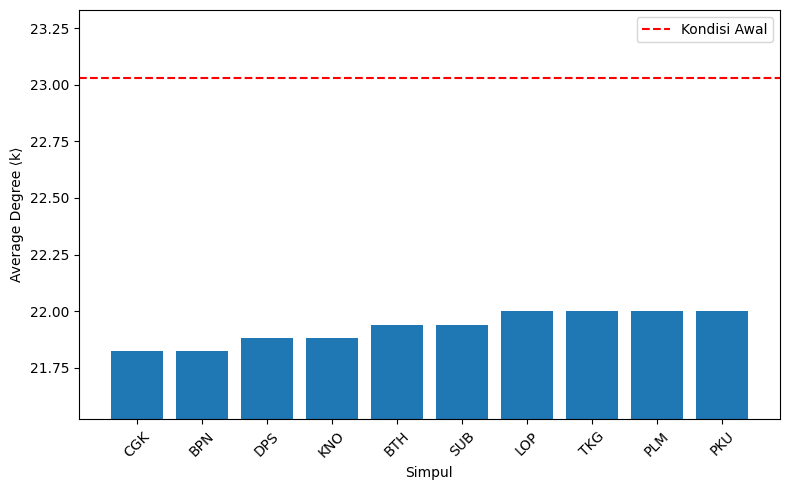

In [ ]:
top10_k = df_viz.sort_values("Δk", ascending=False).head(10)

x = range(len(top10_k))

plt.figure(figsize=(8,5))

# Bar chart
plt.bar(x, top10_k["<k>"])

# Garis kondisi awal (topologi awal)
plt.axhline(
    baseline["<k>"],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Kondisi Awal'
)

plt.xticks(x, top10_k["Removed_Node"], rotation=45)
plt.ylabel("Average Degree ⟨k⟩")
plt.xlabel("Simpul")

# Zoom proporsional
y_min = top10_k["<k>"].min()
y_max = baseline["<k>"]
range_data = y_max - y_min
margin = 0.25 * range_data

plt.ylim(y_min - margin, y_max + margin)

plt.legend()
plt.tight_layout()
plt.show()


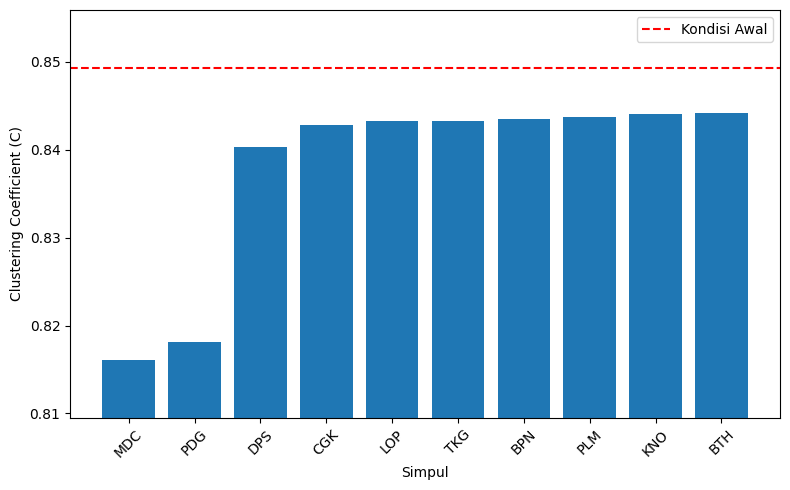

In [ ]:
top10_C = df_viz.sort_values("ΔC", ascending=False).head(10)

x = range(len(top10_C))

plt.figure(figsize=(8,5))

# Bar chart
plt.bar(x, top10_C["C"])

# Garis topologi awal (merah)
plt.axhline(
    baseline["C"],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Kondisi Awal'
)

plt.xticks(x, top10_C["Removed_Node"], rotation=45)
plt.ylabel("Clustering Coefficient (C)")
plt.xlabel("Simpul")

# 🔹 Zoom dengan margin 20%
y_min = top10_C["C"].min()
y_max = baseline["C"]

range_data = y_max - y_min
margin = 0.20 * range_data

plt.ylim(y_min - margin, y_max + margin)

plt.legend()
plt.tight_layout()
plt.show()


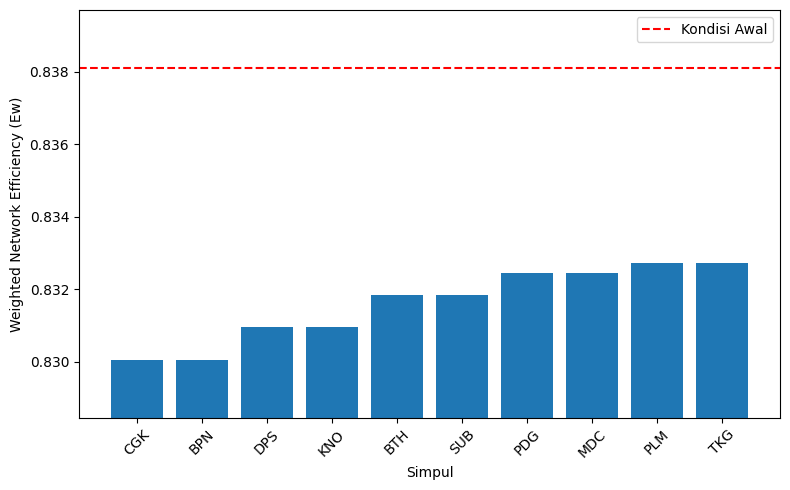

In [ ]:
top10_Ew = df_viz.sort_values("ΔEw", ascending=False).head(10)

x = range(len(top10_Ew))

plt.figure(figsize=(8,5))

# Bar chart
plt.bar(x, top10_Ew["Ew"])

# Garis topologi awal (merah)
plt.axhline(
    baseline["Ew"],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Kondisi Awal'
)

plt.xticks(x, top10_Ew["Removed_Node"], rotation=45)
plt.ylabel("Weighted Network Efficiency (Ew)")
plt.xlabel("Simpul")

# 🔹 Zoom dengan margin 20%
y_min = top10_Ew["Ew"].min()
y_max = baseline["Ew"]

range_data = y_max - y_min
margin = 0.20 * range_data

plt.ylim(y_min - margin, y_max + margin)

plt.legend()
plt.tight_layout()
plt.show()


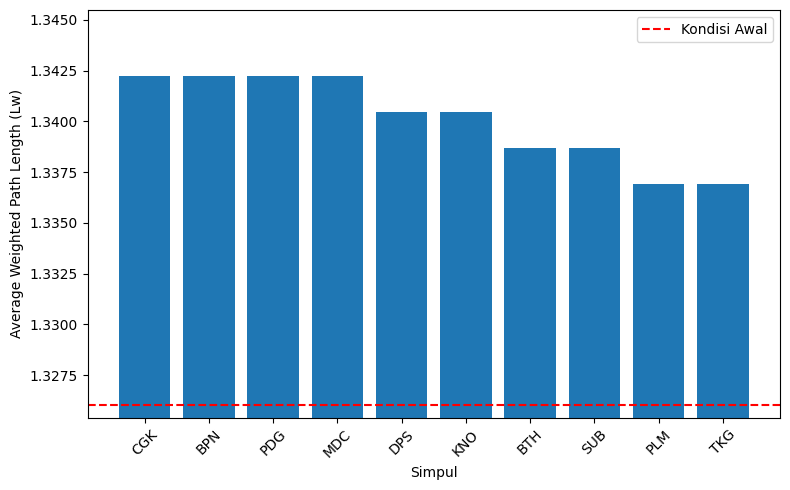

In [ ]:
# ΔLw sudah didefinisikan
# df_viz["ΔLw"] = df_viz["Lw"] - baseline["Lw"]

top10_Lw = df_viz.sort_values("ΔLw", ascending=False).head(10)

x = range(len(top10_Lw))

plt.figure(figsize=(8,5))

# Bar nilai Lw asli
plt.bar(x, top10_Lw["Lw"])

# Garis baseline di 1.32
plt.axhline(
    baseline["Lw"],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Kondisi Awal'
)

plt.xticks(x, top10_Lw["Removed_Node"], rotation=45)
plt.ylabel("Average Weighted Path Length (Lw)")
plt.xlabel("Simpul")

# 🔥 Fokus ke sekitar 1.32
y_min = baseline["Lw"]
y_max = top10_Lw["Lw"].max()

range_data = y_max - y_min
margin = 0.20 * range_data

plt.ylim(y_min - margin*0.2, y_max + margin)

plt.legend()
plt.tight_layout()
plt.show()


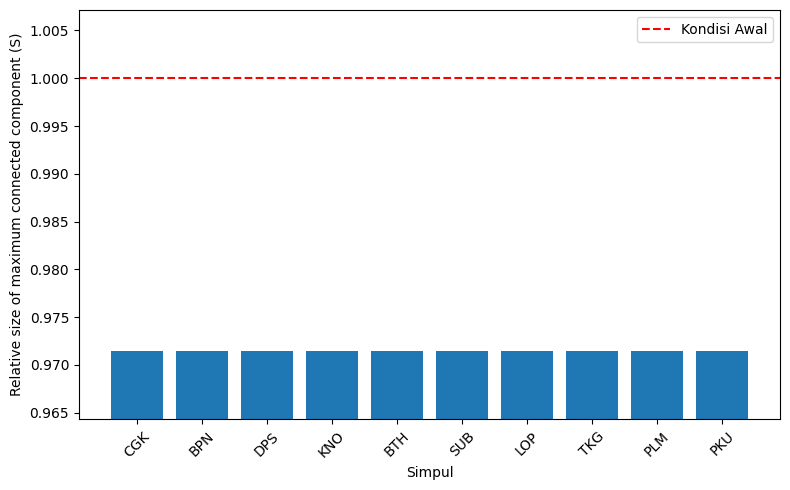

In [ ]:
top10_S = df_viz.sort_values("ΔS", ascending=False).head(10)

x = range(len(top10_S))

plt.figure(figsize=(8,5))

# Bar chart
plt.bar(x, top10_S["S"])

# Garis kondisi awal (topologi awal)
plt.axhline(
    baseline["S"],
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Kondisi Awal'
)

plt.xticks(x, top10_k["Removed_Node"], rotation=45)
plt.ylabel("Relative size of maximum connected component (S)")
plt.xlabel("Simpul")

# Zoom proporsional
y_min = top10_k["S"].min()
y_max = baseline["S"]
range_data = y_max - y_min
margin = 0.25 * range_data

plt.ylim(y_min - margin, y_max + margin)

plt.legend()
plt.tight_layout()
plt.show()


#Sequential Node Removal

In [ ]:
# ============================
#  WLEC A
# ============================

# 1. Daftar node urut berdasarkan WLEC
wlec_a = [ "CGK", "KNO", "DPS", "PKU", "BPN", "UPG", "YIA", "SUB", "PLM", "PNK",
    "BTH", "PDG", "LOP", "BDJ", "MDC", "AMQ", "TKG", "SRG", "BTJ", "SOQ",
    "SOC", "DJJ", "KOE", "TJQ", "LBJ", "AAP", "TRK", "PLW", "TNJ", "BIK",
    "DTB", "HLP", "MKQ", "BWX", "KJT"]

N_initial = len(G)

# ---- Fungsi metrik (sama dengan versi kamu) ----
def average_degree(G):
    return np.mean([d for _, d in G.degree()]) if len(G) > 0 else 0

def average_clustering(G):
    return np.mean(list(nx.clustering(G).values())) if len(G) > 0 else 0

def largest_connected_component_ratio(G):
    if len(G) == 0:
        return 0
    largest_cc = max(nx.connected_components(G), key=len)
    return len(largest_cc) / N_initial

def weighted_efficiency(G):
    if len(G) <= 1:
        return 0
    H = G.copy()
    for u, v, data in H.edges(data=True):
        w = data.get("Weight", 1)
        data["cost"] = 1 / w if w > 0 else 1e9

    path_lengths = dict(nx.all_pairs_dijkstra_path_length(H, weight="cost"))
    n = len(G)
    eff_sum = 0
    for u in G.nodes():
        for v in G.nodes():
            if u != v:
                try:
                    eff_sum += 1 / path_lengths[u][v]
                except KeyError:
                    pass
    return eff_sum / (n * (n - 1))

def average_weighted_path_length(G):
    if len(G) <= 1:
        return 0
    H = G.copy()
    for u, v, data in H.edges(data=True):
        w = data.get("Weight", 1)
        data["cost"] = 1 / w if w > 0 else 1e9
    if not nx.is_connected(H):
        largest_cc = max(nx.connected_components(H), key=len)
        H = H.subgraph(largest_cc).copy()
    return nx.average_shortest_path_length(H, weight="cost")

# 3. Baseline
baseline_a = {
    "<k>": average_degree(G),
    "C": average_clustering(G),
    "S": largest_connected_component_ratio(G),
    "Ew": weighted_efficiency(G),
    "Lw": average_weighted_path_length(G),
}

# 4. Sequential removal WLEC-A
results_a = []
G_a = G.copy()
step = 0

results_a.append({
    "Step": step,
    "Removed": "NONE",
    **baseline_a
})

for node in wlec_a:
    step += 1
    if node in G_a:
        G_a.remove_node(node)
    metrics = {
        "<k>": average_degree(G_a),
        "C": average_clustering(G_a),
        "S": largest_connected_component_ratio(G_a),
        "Ew": weighted_efficiency(G_a),
        "Lw": average_weighted_path_length(G_a),
    }
    results_a.append({
        "Step": step,
        "Removed": node,
        **metrics
    })

df_seq_a = pd.DataFrame(results_a)
print(df_seq_a)


    Step Removed        <k>         C         S        Ew        Lw
0      0    NONE  23.028571  0.849286  1.000000  0.950459  1.464576
1      1     CGK  21.823529  0.842834  0.971429  0.862496  1.590952
2      2     KNO  20.666667  0.837114  0.942857  0.815750  1.666823
3      3     DPS  19.500000  0.826107  0.914286  0.774472  1.747265
4      4     PKU  18.451613  0.819196  0.885714  0.743684  1.795200
5      5     BPN  17.200000  0.809772  0.857143  0.709458  1.868526
6      6     UPG  16.137931  0.801326  0.828571  0.680656  1.938353
7      7     YIA  15.142857  0.803608  0.800000  0.640777  2.032570
8      8     SUB  14.000000  0.806623  0.771429  0.561947  2.399918
9      9     PLM  12.923077  0.790013  0.742857  0.528597  2.521480
10    10     PNK  12.080000  0.784364  0.714286  0.504132  2.618349
11    11     BTH  10.916667  0.770479  0.685714  0.452134  2.920413
12    12     PDG   9.913043  0.675840  0.657143  0.437263  3.040861
13    13     LOP   8.818182  0.644717  0.628571 

In [ ]:
import random

# ============================
#  Random Node Removal
# ============================

# 1. Ambil daftar semua node dari graph
nodes_list = list(G.nodes())

# 2. Acak urutannya
random.shuffle(nodes_list)

# 3. Baseline (seperti sebelumnya)
baseline_random = {
    "<k>": average_degree(G),
    "C": average_clustering(G),
    "S": largest_connected_component_ratio(G),
    "Ew": weighted_efficiency(G),
    "Lw": average_weighted_path_length(G),
}

# 4. Sequential removal random
results_random = []
G_rand = G.copy()
step = 0

# Tambahkan baseline
results_random.append({
    "Step": step,
    "Removed": "NONE",
    **baseline_random
})

# Hapus node satu per satu sesuai urutan acak
for node in nodes_list:
    step += 1
    if node in G_rand:
        G_rand.remove_node(node)
    metrics = {
        "<k>": average_degree(G_rand),
        "C": average_clustering(G_rand),
        "S": largest_connected_component_ratio(G_rand),
        "Ew": weighted_efficiency(G_rand),
        "Lw": average_weighted_path_length(G_rand),
    }
    results_random.append({
        "Step": step,
        "Removed": node,
        **metrics
    })

df_random = pd.DataFrame(results_random)
print(df_random)


    Step Removed        <k>         C         S        Ew        Lw
0      0    NONE  23.028571  0.849286  1.000000  0.950459  1.464576
1      1     LBJ  22.647059  0.855801  0.971429  0.957463  1.467949
2      2     YIA  21.696970  0.855916  0.942857  0.937007  1.496382
3      3     PNK  20.812500  0.854054  0.914286  0.923729  1.521604
4      4     DPS  19.677419  0.844725  0.885714  0.893207  1.558329
5      5     DTB  19.733333  0.858496  0.857143  0.914233  1.537062
6      6     PDG  18.758621  0.823330  0.828571  0.896714  1.573942
7      7     KNO  17.571429  0.816136  0.800000  0.857768  1.623450
8      8     BDJ  16.740741  0.807728  0.771429  0.844763  1.652348
9      9     MDC  15.692308  0.800222  0.714286  0.813562  1.473992
10    10     SOQ  14.960000  0.793947  0.685714  0.814272  1.482180
11    11     BWX  15.166667  0.797570  0.657143  0.862115  1.282496
12    12     PKU  14.173913  0.786449  0.628571  0.821880  1.317412
13    13     UPG  13.090909  0.773401  0.600000 

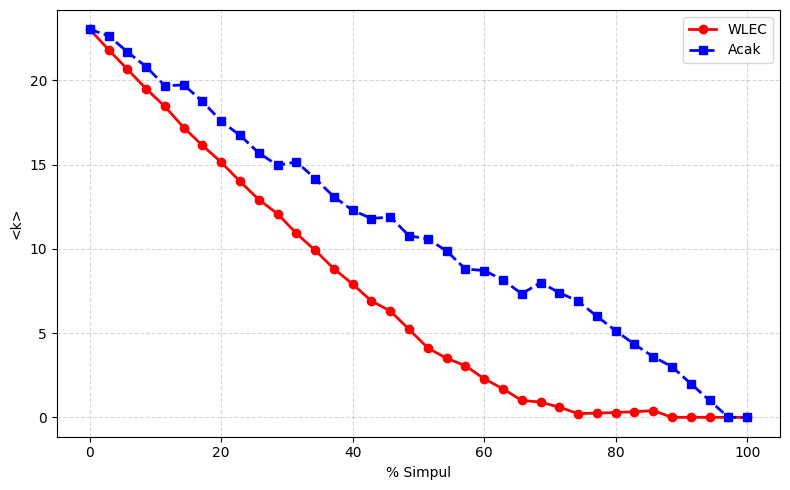

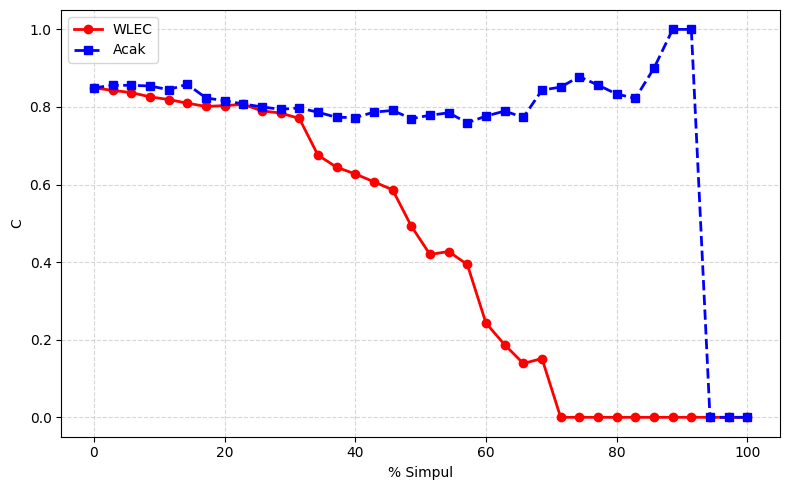

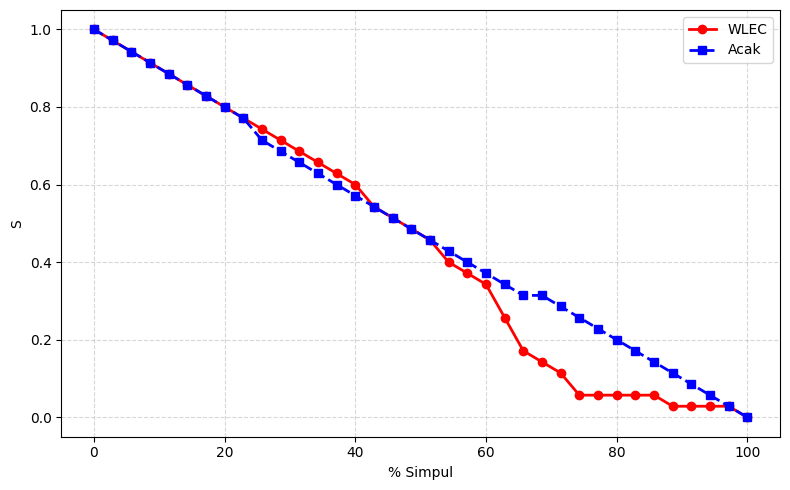

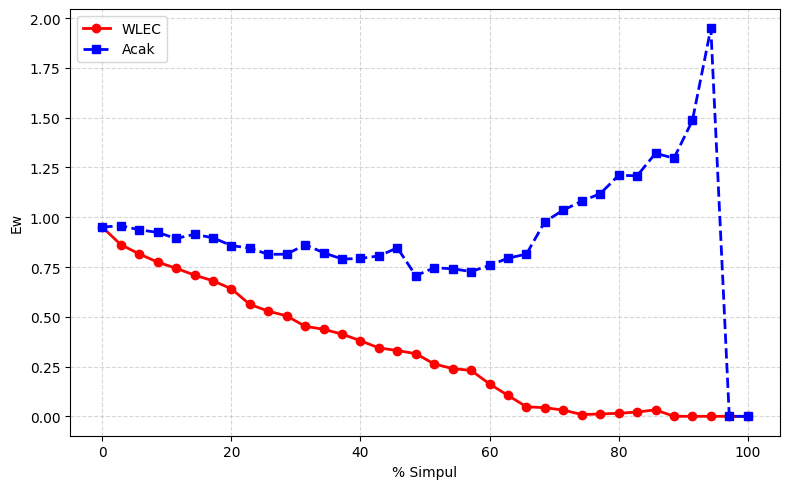

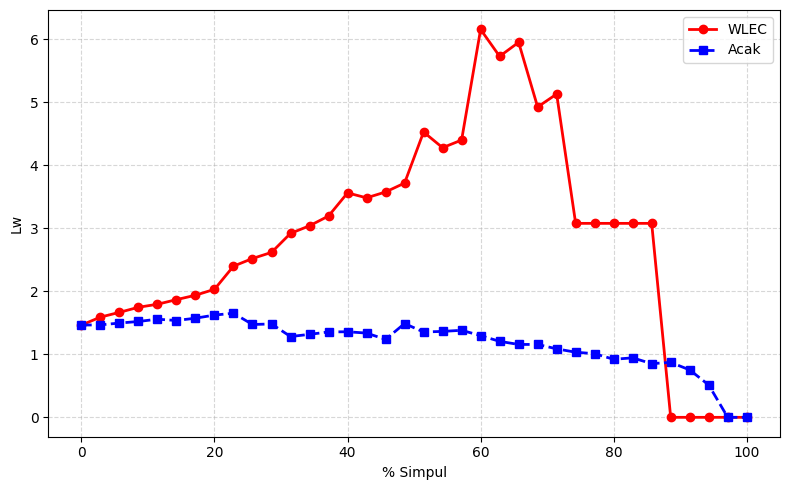

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["<k>", "C", "S", "Ew", "Lw"]
labels = ["<k>", "C", "S", "Ew", "Lw"]

# Total simpul awal (WAJIB dari graph awal)
N = len(df_seq_a) - 1
# asumsi baris ke-0 = 0% removal

# Sumbu X dalam persen
x_percent = np.linspace(0, 100, len(df_seq_a))

for i, metric in enumerate(metrics):
    plt.figure(figsize=(8, 5))

    # WLEC (MERAH)
    plt.plot(
        x_percent,
        df_seq_a[metric],
        marker='o',
        linestyle='-',
        color='red',
        linewidth=2,
        label='WLEC'
    )

    # RANDOM (BIRU)
    plt.plot(
        x_percent,
        df_random[metric],
        marker='s',
        linestyle='--',
        color='blue',
        linewidth=2,
        label='Acak'
    )

    plt.xlabel("% Simpul")
    plt.ylabel(labels[i])

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()

    plt.tight_layout()
    plt.show()




---



---



In [ ]:
gajyeeybjkukskfbhb

NameError: name 'gajyeeybjkukskfbhb' is not defined

## Jumlah node dan edge

In [ ]:
print("Jumlah node :", G.number_of_nodes())
print("Jumlah edge :", G.number_of_edges())

## Distribusi Derajat Tiap Simpul

In [ ]:
# Hitung derajat tiap simpul
degree_dict = dict(G.degree())
# Urutkan berdasarkan derajat tertinggi ke rendah (descending)
sorted_degrees = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
# Tampilkan semua derajat
degree_df = pd.DataFrame(sorted_degrees, columns=["IATA", "Degree"])
degree_df


In [ ]:
# Visualisasi bar chart distribusi derajat tiap simpul
plt.figure(figsize=(12,6))
plt.bar(degree_df["IATA"], degree_df["Degree"])
plt.xlabel("Bandara (IATA)")
plt.ylabel("Degree (Jumlah Koneksi)")
plt.title("Distribusi Derajat Bandara")
plt.xticks(rotation=90)
plt.show()

## List Tetangga Tiap Simpul

In [ ]:
# Daftar koneksi semua bandara
for node in G.nodes:
    tetangga = list(G.neighbors(node))
    print(f"{node} → {tetangga}")

## Proporsi Derajat

In [ ]:
# Hitung derajat tiap simpul
degree_dict = dict(G.degree())
degrees = list(degree_dict.values())

# Hitung distribusi p(k)
degree_count = pd.Series(degrees).value_counts().sort_index()
pk = degree_count / degree_count.sum()  # proporsi

# --- Visualisasi
plt.figure(figsize=(8,5))
plt.bar(pk.index, pk.values, width=0.9, color="white", edgecolor="black", linewidth=1.0)

plt.xlabel("k (Degree)", fontsize=12)
plt.ylabel("p(k) (Proportion)", fontsize=12)
plt.title("Degree Distribution of Airport Network", fontsize=13, weight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.6, linewidth=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# Hitung derajat tiap simpul
degree_dict = dict(G.degree())
degrees = list(degree_dict.values())

# Hitung distribusi p(k)
degree_count = pd.Series(degrees).value_counts().sort_index()
pk = degree_count / degree_count.sum()  # proporsi

# --- Visualisasi ---
plt.figure(figsize=(8,5))
plt.plot(pk.index, pk.values, color="black", linewidth=1.5, marker="o", markersize=4)

plt.xlabel("k (Degree)", fontsize=12)
plt.ylabel("p(k) (Proportion)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.6, linewidth=0.6)
plt.tight_layout()
plt.show()


# Matriks ketetanggan

In [ ]:
gshgdygs

In [ ]:
data

In [ ]:
def adjacency_matrix_weighted(G, nodelist=None):
    if nodelist is None:
        nodelist = list(G.nodes())

    A = nx.to_numpy_array(
        G,
        nodelist=nodelist,
        weight='Weight_norm',
        dtype=float
    )
    return A, nodelist


In [ ]:
A, nodes = adjacency_matrix_weighted(G)

print("Urutan simpul (baris/kolom):")
print(nodes)

print("\nMatriks Ketetanggaan Berbobot A:")
print(np.round(A, 4))


# Weighted Laplacian Energy Centrality

In [ ]:
# Utility: buat adjacency matrix berbobot sesuai urutan node
def adjacency_matrix_weighted(G: nx.Graph, nodelist: List = None) -> np.ndarray:
    if nodelist is None:
        nodelist = list(G.nodes())     # Mengambil daftar node
    A = nx.to_numpy_array(G, nodelist=nodelist, weight='Weight', dtype=float)  # buat matriks adjacency berbobot
    return A

# Utility: buat matriks derajat (degree/strength) diagonal dari adjacency
def degree_matrix_from_adj(A: np.ndarray) -> np.ndarray:
    s = A.sum(axis=1)                  # jumlah bobot per baris = total koneksi node
    D = np.diag(s)                     # ubah menjadi matriks diagonal
    return D

# Utility: bangun Laplacian L = D - A
def weighted_laplacian(A: np.ndarray) -> np.ndarray:
    D = degree_matrix_from_adj(A)      # hitung matriks derajat
    return D - A                       # rumus dasar Laplacian berbobot (L=D-A)

# Utility: hitung trace(L^k) menggunakan numpy (jejak dari matriks berpangkat k)
def trace_power(L: np.ndarray, k: int) -> float:
    Lk = np.linalg.matrix_power(L, k)  # pangkatkan matriks L sebanyak k kali
    return float(np.trace(Lk))         # ambil nilai trace (jumlah elemen diagonal)

# Fungsi utama: hitung Weighted Laplacian Energy Centrality untuk semua node
def weighted_laplacian_energy_centrality(G: nx.Graph, k: int = 3):
    G0 = deepcopy(G)                   # salin graph agar data asli tidak berubah
    nodes = list(G0.nodes())           # ambil daftar semua node
    n = len(nodes)                     # simpan jumlah node

    # Hitung matriks adjacency & Laplacian untuk graph asli
    A = adjacency_matrix_weighted(G0, nodelist=nodes)
    L = weighted_laplacian(A)
    E_Lk_G = trace_power(L, k)         # hitung energi Laplacian berpangkat k => tr(L^k)
    print(f"E_L^{k}(G) = {E_Lk_G:.6f}") # tampilkan nilai energi total graph (6 angka di belakang koma)

    # Loop untuk menghitung LC^k(v) setiap node
    results = []
    for i, v in enumerate(nodes):
        G_minus = G0.copy()            # salin graph
        G_minus.remove_node(v)         # hapus node v untuk lihat dampaknya

        if len(G_minus) == 0:          # jika semua node terhapus
            E_minus = 0.0              # maka energinya nol
        else:
            nodes_minus = list(G_minus.nodes())  # ambil node tersisa
            A_minus = adjacency_matrix_weighted(G_minus, nodelist=nodes_minus)
            L_minus = weighted_laplacian(A_minus)
            E_minus = trace_power(L_minus, k)    # hitung energi setelah node dihapus

        LC_v = E_Lk_G - E_minus        # selisih energi = nilai centrality node v yaitu energi total dikurangi energi setelah simpul dihapus
        results.append({
            "node": v,
            f"E_L{k}_G_minus_v": E_minus,
            f"LC{k}(v)": LC_v
        })

    # Simpan hasil ke DataFrame dan urutkan berdasarkan nilai LC menurun
    df_res = pd.DataFrame(results)
    df_res = df_res.sort_values(by=f"LC{k}(v)", ascending=False).reset_index(drop=True)
    return E_Lk_G, df_res

# Jalankan fungsi dengan k = 3
k = 3
E_L3_G, df_centrality = weighted_laplacian_energy_centrality(G, k=k)

# Tampilkan hasil
print("\nHasil Weighted Laplacian Energy Centrality (k=3):")
print(tabulate(df_centrality, headers='keys', tablefmt='fancy_grid', showindex=True))


In [ ]:
bbbmhsgy

## Tampilan matriks ketetanggan berbobot

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from copy import deepcopy
from tabulate import tabulate

# Utility: buat adjacency matrix berbobot sesuai urutan node
def adjacency_matrix_weighted(G: nx.Graph, nodelist=None, verbose=False, label=""):
    if nodelist is None:
        nodelist = list(G.nodes())

    A = nx.to_numpy_array(
        G,
        nodelist=nodelist,
        weight='Weight_norm',
        dtype=float
    )

    if verbose:
        print(f"\nAdjacency Matrix A {label}")
        print("Urutan node:", nodelist)
        print(A)

    return A

# Utility: buat matriks derajat (strength) diagonal
def degree_matrix_from_adj(A: np.ndarray, verbose=False, label=""):
    s = A.sum(axis=1)
    D = np.diag(s)

    if verbose:
        print(f"\nDegree Matrix D {label}")
        print(D)

    return D

# Utility: bangun Laplacian berbobot L = D - A
def weighted_laplacian(A: np.ndarray, verbose=False, label=""):
    D = degree_matrix_from_adj(A, verbose=verbose, label=label)
    L = D - A

    if verbose:
        print(f"\nWeighted Laplacian L {label}")
        print(L)

    return L

# Utility: trace(L^k)
def trace_power(L: np.ndarray, k: int, verbose=False, label=""):
    Lk = np.linalg.matrix_power(L, k)

    if verbose:
        print(f"\nL^{k} {label}")
        print(Lk)
        print(f"trace(L^{k}) = {np.trace(Lk)}")

    return float(np.trace(Lk))

# Fungsi utama WLEC
def weighted_laplacian_energy_centrality(G: nx.Graph, k: int = 3, verbose=True):
    G0 = deepcopy(G)
    nodes = list(G0.nodes())

    print("\n================ GRAPH ASLI ================")
    A = adjacency_matrix_weighted(G0, nodes, verbose=verbose, label="(G)")
    L = weighted_laplacian(A, verbose=verbose, label="(G)")
    E_Lk_G = trace_power(L, k, verbose=verbose, label="(G)")

    print(f"\nE_L^{k}(G) = {E_Lk_G:.6f}")

    results = []

    for v in nodes:
        print(f"\n=========== HAPUS NODE {v} ===========")

        G_minus = G0.copy()
        G_minus.remove_node(v)

        if len(G_minus) == 0:
            E_minus = 0.0
        else:
            nodes_minus = list(G_minus.nodes())

            A_minus = adjacency_matrix_weighted(
                G_minus,
                nodes_minus,
                verbose=verbose,
                label=f"(G - {v})"
            )

            L_minus = weighted_laplacian(
                A_minus,
                verbose=verbose,
                label=f"(G - {v})"
            )

            E_minus = trace_power(
                L_minus,
                k,
                verbose=verbose,
                label=f"(G - {v})"
            )

        LC_v = E_Lk_G - E_minus

        results.append({
            "node": v,
            f"E_L{k}(G-v)": E_minus,
            f"LC{k}(v)": LC_v
        })

    df_res = pd.DataFrame(results)
    df_res = df_res.sort_values(by=f"LC{k}(v)", ascending=False).reset_index(drop=True)

    return E_Lk_G, df_res


In [ ]:
k = 3
E_L3_G, df_centrality = weighted_laplacian_energy_centrality(G, k=k, verbose=True)

print("\nHasil Weighted Laplacian Energy Centrality (k=3):")
print(tabulate(df_centrality, headers='keys', tablefmt='fancy_grid', showindex=True))


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx

def show_adjacency_matrix(G):
    nodes = list(G.nodes())
    A = nx.to_numpy_array(
        G,
        nodelist=nodes,
        weight='Weight_norm',
        dtype=float
    )

    A_df = pd.DataFrame(
        np.round(A, 4),
        index=nodes,
        columns=nodes
    )

    print("\n=== Matriks Ketetanggaan Berbobot A(G) ===")
    print(A_df)

    return A
A = show_adjacency_matrix(G)

In [ ]:
vghkkkkk

## Bentuk Matriks

In [ ]:
import pandas as pd
import networkx as nx

# Matriks Laplacian sparse
L_sparse = nx.laplacian_matrix(G, weight='Weight_norm')

# Konversi ke array numpy
L_array = L_sparse.toarray()

# Buat DataFrame pandas agar lebih mudah dibaca, label kolom dan indeksnya pakai nama node
L_df = pd.DataFrame(L_array, index=G.nodes(), columns=G.nodes())

# Tampilkan
print("Matriks Laplacian Jaringan (berat edge dipertimbangkan):")
display(L_df)  # Di Jupyter/Colab agar tampil tabel rapi

# Jika tidak di Jupyter, bisa pakai print(L_df) untuk output string tabel


## Karakteristik WLEC

Weighted Laplacian Energy Centrality (WLEC) dijelaskan sebagai ukuran pentingnya sebuah node (simpul) dalam sebuah jaringan berbobot berdasarkan perubahan energi Laplacian jaringan ketika node tersebut dihapus. Energi Laplacian itu sendiri berasal dari matriks Laplacian berbobot, yang dibentuk dari matriks derajat diagonal dan matriks adjacency berbobot.

Berikut karakteristik yang membuat suatu node memiliki nilai centrality tinggi pada Weighted Laplacian Energy Centrality:

*   Derajat berbobot (strength) node: Semakin besar jumlah total bobot sisi yang terhubung ke sebuah node, maka pengaruh node itu terhadap energi Laplacian juga semakin besar. Node dengan "hubungan" yang kuat atau banyak akan meningkatkan nilai centrality.
*   Posisi dan peran node dalam jaringan: Node yang berperan sebagai penghubung antara bagian-bagian jaringan atau menghubungkan cluster-cluster penting akan membuat perubahan energi Laplacian yang cukup besar jika dihapus, sehingga centrality-nya tinggi.
*   Struktur lokal di sekitar node: Node dengan lingkungan yang sangat terkoneksi atau memiliki tetangga dengan pengaruh besar juga akan memiliki nilai centrality yang tinggi karena kontribusinya pada energi spektral jaringan.
*   WLEC menggabungkan informasi bobot dan struktur jaringan secara spektral (berdasarkan eigenvalue dan trace dari matriks Laplacian pangkat k), sehingga bukan hanya jumlah koneksi, tetapi juga bagaimana koneksi tersebut memengaruhi difusi atau aliran dalam jaringan.


Secara matematis, WLEC mengukur seberapa besar perubahan energi total jaringan (trace dari Lk, dengan L adalah matriks Laplacian) saat sebuah node dihilangkan, yang mencerminkan pengaruh node itu terhadap kestabilan dan fungsi jaringan. Dengan demikian, node dengan nilai centrality tinggi adalah node yang secara signifikan menyokong kekuatan terkoneksi dan struktur jaringan secara keseluruhan.

# Topologi Jaringan

In [ ]:

# 2. Hitung N awal (jumlah node)
N_initial = len(G)  # Menghitung jumlah node awal (bandara)

# <k>: Rata-rata degree/titik (unweighted)
def average_degree(G):  # Definisi fungsi untuk menghitung rata-rata derajat node (unweighted, tanpa bobot)
    degrees = [d for n, d in G.degree()]  # Mengumpulkan derajat (jumlah koneksi) setiap node
    return np.mean(degrees)  # Mengembalikan rata-rata derajat menggunakan NumPy

# C: Clustering coefficient rata-rata (unweighted)
def average_clustering(G):  # Definisi fungsi untuk menghitung rata-rata koefisien clustering (seberapa saling terhubung tetangga node)
    return np.mean(list(nx.clustering(G).values()))  # Menggunakan NetworkX untuk hitung clustering per node, lalu rata-rata

# Lw: Weighted average shortest path length (cost=1/weight, pada biggest CC saja jika tidak terhubung)
def average_weighted_path_length(G):  # Definisi fungsi untuk rata-rata panjang jalur terpendek berbobot
    if len(G) <= 1: return 0  # Jika graf <=1 node, panjang 0
    H = G.copy()  # Salin graf
    for u, v, data in H.edges(data=True):  # Loop setiap edge untuk set cost
        w = data.get("Weight_norm", 1)  # Ambil Weight
        data["cost"] = 1 / w if w > 0 else 1e9  # Set cost = 1/Weight => semakin besar bobot maka semakin baik
    if not nx.is_connected(H):  # Jika graf tidak terhubung
        largest_cc = max(nx.connected_components(H), key=len)  # Cari komponen terbesar
        H = H.subgraph(largest_cc).copy()  # Buat subgraph hanya komponen terbesar
    return nx.average_shortest_path_length(H, weight="cost")  # Hitung rata-rata panjang jalur terpendek berbobot pada subgraph

# Hitung metrik-metrik global jaringan
network_metrics = {  # Buat dictionary untuk menyimpan hasil metrik
    "<k>": average_degree(G),  # Panggil fungsi <k>
    "C": average_clustering(G),  # Panggil fungsi C
    "Lw": average_weighted_path_length(G)  # Panggil fungsi Lw
}

# Export ke DataFrame satu baris
df_metrics = pd.DataFrame([network_metrics])  # Buat DataFrame Pandas dari dictionary (satu baris)

# Tampilkan
print(df_metrics)  # Cetak DataFrame ke konsol untuk output


# CENTRALITY

In [ ]:
data.columns

## Strength Centrality (SC)

In [ ]:

from tabulate import tabulate
import networkx as nx

# Bangun graf dari data
G = nx.from_pandas_edgelist(df, 'IATA_Origin', 'IATA_Destination', edge_attr='Weight_norm', create_using=nx.Graph())

# Hitung Strength Centrality (total bobot tiap simpul)
strength_centrality = {}
for node in G.nodes():
    total_weight = sum(d['Weight_norm'] for _, _, d in G.edges(node, data=True))
    strength_centrality[node] = total_weight

# Konversi ke DataFrame dan urutkan ===
df_strength = pd.DataFrame(list(strength_centrality.items()),
                           columns=['Node', 'Strength_Centrality']).sort_values(by='Strength_Centrality', ascending=False)

# Tampilkan hasil teratas ===
print(tabulate(df_strength.head(10), headers='keys', tablefmt='fancy_grid', showindex=True))


Strength Centrality mengukur pentingnya sebuah node berdasarkan total bobot koneksi langsungnya. Jika bobot sisi adalah jumlah maskapai, maka Strength Centrality sebuah bandara dihitung dengan menjumlahkan semua maskapai pada rute yang terhubung langsung ke bandara itu.

Semakin banyak maskapai yang melayani rute langsung ke sebuah bandara, semakin besar nilai Strength Centrality-nya, yang menunjukkan keterhubungan yang lebih kuat dan lebih beragam pilihan penerbangan langsung bagi penumpang. Dengan adanya banyak maskapai dan rute alternatif, jaringan penerbangan menjadi lebih tahan terhadap gangguan atau kegagalan pada beberapa rute.

## Betwennes Centrality (BC)

Sebuah bandara punya betweenness centrality tinggi jika banyak jalur dengan total bobot minimum (misalnya waktu tempuh/biaya terendah) antara dua bandara lain melewati bandara tersebut.

Namun dalam hal ini, jika bobot adalah jumlah maskapai maka => Semakin sedikit maskapai → nilai bobot lebih kecil → BC naik.

Ini bertentangan dengan logika nyata jaringan bandara, karena:
*   Rute dengan sedikit maskapai biasanya kurang penting atau kurang menarik.
*   Rute dengan banyak maskapai seharusnya lebih dominan, lebih sering dilewati, tapi algoritma justru “menganggap lebih panjang”.



In [ ]:


# Hitung Betweenness Centrality menggunakan bobot yang telah di normalisasi
betweenness_centrality = nx.betweenness_centrality(G, weight='Weight_norm', normalized=True)

# Konversi ke DataFrame dan urutkan
df_bc = pd.DataFrame(list(betweenness_centrality.items()),
                     columns=['Node', 'Betweenness_Centrality']).sort_values(by='Betweenness_Centrality', ascending=False)

# Tampilkan hasil
df_bc.head(10)

## Closeness Centrality (CC)



*   Bandara dengan CC tinggi adalah bandara yang strategis dan terhubung langsung dengan banyak rute padat, atau dapat mencapai bandara lain melalui jalur yang didominasi maskapai ramai.
*   Bandara dengan CC rendah biasanya terpencil, punya sedikit koneksi langsung, dan hanya bisa menjangkau jaringan lain lewat rute berfrekuensi rendah.


**Bandara dengan CC tinggi berperan sebagai hub penting yang mempercepat akses antarwilayah, sedangkan CC rendah menunjukkan bandara perifer dengan konektivitas lemah.**



In [ ]:
# --- Hitung closeness centrality berbobot ---
closeness_centrality_weighted = nx.closeness_centrality(G, distance='Weight_norm')

# --- Tampilkan hasil ---
df_cc = pd.DataFrame({
    'IATA_Code': list(closeness_centrality_weighted.keys()),
    'Closeness_Centrality_Weighted': list(closeness_centrality_weighted.values())
}).sort_values(by='Closeness_Centrality_Weighted', ascending=False)

df_cc.head(10)

## Eigenvector Centrality (EC)


Semakin tinggi nilai eigenvector centrality sebuah bandara, semakin besar pengaruhnya dalam jaringan penerbangan, karena terhubung dengan banyak bandara penting melalui rute-rute yang ramai dan sering dilayani.

In [ ]:
# Hitung Eigenvector Centrality
eigenvector_centrality = nx.eigenvector_centrality(G, weight='Weight_norm', max_iter=1000)

# Simpan ke DataFrame
df_ec = pd.DataFrame(list(eigenvector_centrality.items()), columns=['Node', 'Eigenvector_Centrality'])

# Urutkan dari tertinggi ke terendah
df_ec = df_ec.sort_values(by='Eigenvector_Centrality', ascending=False)

# Tampilkan hasil
df_ec

## Centrality

In [ ]:
# === Hitung semua centrality ===
# === Normalisasi bobot ===
# Bobot besar = banyak maskapai = jalur lebih kuat (lebih “pendek”), maka dibalik
for u, v, d in G.edges(data=True):
    d['cost'] = 1 / d['Weight_norm']

# Degree Centrality (berdasarkan jumlah koneksi)
dc = nx.degree_centrality(G)

# Strength Centrality (total bobot koneksi tiap simpul)
strength_centrality = {}
for node in G.nodes():
    total_weight = sum(d['Weight_norm'] for _, _, d in G.edges(node, data=True))
    strength_centrality[node] = total_weight

# Betweenness Centrality (menggunakan bobot dibalik)
bc = nx.betweenness_centrality(G, weight='cost', normalized=True)

# Closeness Centrality (menggunakan bobot dibalik)
cc = nx.closeness_centrality(G, distance='cost')

# Eigenvector Centrality (berdasarkan bobot asli)
ec = nx.eigenvector_centrality(G, weight='Weight_norm', max_iter=1000)

# === Konversi ke DataFrame dan ambil Top 10 ===
df_dc = pd.DataFrame(sorted(dc.items(), key=lambda x: x[1], reverse=True), columns=['Node', 'Degree_Centrality'])
df_strength = pd.DataFrame(sorted(strength_centrality.items(), key=lambda x: x[1], reverse=True), columns=['Node', 'Strength_Centrality'])
df_bc = pd.DataFrame(sorted(bc.items(), key=lambda x: x[1], reverse=True), columns=['Node', 'Betweenness_Centrality'])
df_cc = pd.DataFrame(sorted(cc.items(), key=lambda x: x[1], reverse=True), columns=['Node', 'Closeness_Centrality'])
df_ec = pd.DataFrame(sorted(ec.items(), key=lambda x: x[1], reverse=True), columns=['Node', 'Eigenvector_Centrality'])

# === Gabungkan ke satu tabel Top 10 ===
ranking = pd.DataFrame({
    'Ranking': range(1, 11),
    'Degree': df_dc['Node'].head(10).values,
    'Strength': df_strength['Node'].head(10).values,
    'Betweenness': df_bc['Node'].head(10).values,
    'Closeness': df_cc['Node'].head(10).values,
    'Eigenvector': df_ec['Node'].head(10).values
})

# === Tampilkan hasil ===
print("\nTable 1. Top 10 Major Airports Obtained by Different Centrality Methods.\n")
print(tabulate(ranking, headers='keys', tablefmt='fancy_grid', showindex=False))

# Weighted Laplacian Energy Centrality (WLEC)

## k=3

In [ ]:
from tabulate import tabulate
# Salin data agar data asli tidak berubah
df = data.copy()                       # buat salinan dataset agar aman

# Bangun graph dari DataFrame (kolom asal, tujuan, dan bobot)
G = nx.from_pandas_edgelist(df, "IATA_Origin", "IATA_Destination",
                            edge_attr="Weight", create_using=nx.Graph())

# Utility: buat adjacency matrix berbobot sesuai urutan node
def adjacency_matrix_weighted(G: nx.Graph, nodelist: List = None) -> np.ndarray:
    if nodelist is None:
        nodelist = list(G.nodes())     # ambil daftar node jika belum diberikan
    A = nx.to_numpy_array(G, nodelist=nodelist, weight='Weight_norm', dtype=float)  # buat matriks adjacency berbobot
    return A

# Utility: buat matriks derajat (degree/strength) diagonal dari adjacency
def degree_matrix_from_adj(A: np.ndarray) -> np.ndarray:
    s = A.sum(axis=1)                  # jumlah bobot per baris = total koneksi node
    D = np.diag(s)                     # ubah menjadi matriks diagonal
    return D

# Utility: bangun Laplacian L = D - A
def weighted_laplacian(A: np.ndarray) -> np.ndarray:
    D = degree_matrix_from_adj(A)      # hitung matriks derajat
    return D - A                       # rumus dasar Laplacian berbobot (L=D-A)

# Utility: hitung trace(L^k) menggunakan numpy (jejak dari matriks berpangkat k)
def trace_power(L: np.ndarray, k: int) -> float:
    Lk = np.linalg.matrix_power(L, k)  # pangkatkan matriks L sebanyak k kali
    return float(np.trace(Lk))         # ambil nilai trace (jumlah elemen diagonal)

# Fungsi utama: hitung Weighted Laplacian Energy Centrality untuk semua node
def weighted_laplacian_energy_centrality(G: nx.Graph, k: int = 3):
    G0 = deepcopy(G)                   # salin graph agar data asli tidak berubah
    nodes = list(G0.nodes())           # ambil daftar semua node
    n = len(nodes)                     # simpan jumlah node

    # Hitung matriks adjacency & Laplacian untuk graph asli
    A = adjacency_matrix_weighted(G0, nodelist=nodes)
    L = weighted_laplacian(A)
    E_Lk_G = trace_power(L, k)         # hitung energi Laplacian berpangkat k => tr(L^k)
    print(f"E_L^{k}(G) = {E_Lk_G:.6f}") # tampilkan nilai energi total graph

    # Loop untuk menghitung LC^k(v) setiap node
    results = []
    for i, v in enumerate(nodes):
        G_minus = G0.copy()            # salin graph
        G_minus.remove_node(v)         # hapus node v untuk lihat dampaknya

        if len(G_minus) == 0:          # jika semua node terhapus
            E_minus = 0.0              # maka energinya nol
        else:
            nodes_minus = list(G_minus.nodes())  # ambil node tersisa
            A_minus = adjacency_matrix_weighted(G_minus, nodelist=nodes_minus)
            L_minus = weighted_laplacian(A_minus)
            E_minus = trace_power(L_minus, k)    # hitung energi setelah node dihapus

        LC_v = E_Lk_G - E_minus        # selisih energi = nilai centrality node v yaitu energi total dikurangi energi setelah simpul dihapus
        results.append({
            "node": v,
            f"E_L{k}_G_minus_v": E_minus,
            f"LC{k}(v)": LC_v
        })

    # Simpan hasil ke DataFrame dan urutkan berdasarkan nilai LC menurun
    df_res = pd.DataFrame(results)
    df_res = df_res.sort_values(by=f"LC{k}(v)", ascending=False).reset_index(drop=True)
    return E_Lk_G, df_res

# Jalankan fungsi dengan k = 3
k = 3
E_L3_G, df_centrality = weighted_laplacian_energy_centrality(G, k=k)

# Tampilkan hasil
print("\nHasil Weighted Laplacian Energy Centrality (k=3):")
print(tabulate(df_centrality, headers='keys', tablefmt='fancy_grid', showindex=True))


### Percobaan Perhitungan dengan k=3

In [ ]:
import numpy as np
import pandas as pd
import networkx as nx
from copy import deepcopy
from typing import List
from tabulate import tabulate

# ===============================
# Dataset kecil (graf berbobot)
# ===============================
coba = pd.DataFrame({
    "IATA_Origin": ["A", "A", "B", "B", "C"],
    "IATA_Destination": ["B", "C", "C", "D", "D"],
    "Weight": [2, 1, 3, 1, 2]
})

# ===============================
# Bangun Graph
# ===============================
df1 = coba.copy()  # salin agar aman
G = nx.from_pandas_edgelist(df1, "IATA_Origin", "IATA_Destination",
                            edge_attr="Weight", create_using=nx.Graph())

# ===============================
# Utility functions
# ===============================
def adjacency_matrix_weighted(G: nx.Graph, nodelist: List = None) -> np.ndarray:
    if nodelist is None:
        nodelist = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodelist, weight='Weight', dtype=float)
    return A

def degree_matrix_from_adj(A: np.ndarray) -> np.ndarray:
    s = A.sum(axis=1)
    D = np.diag(s)
    return D

def weighted_laplacian(A: np.ndarray) -> np.ndarray:
    D = degree_matrix_from_adj(A)
    return D - A

def trace_power(L: np.ndarray, k: int) -> float:
    Lk = np.linalg.matrix_power(L, k)
    return float(np.trace(Lk))

# ===============================
# Fungsi utama: Weighted Laplacian Energy Centrality
# ===============================
def weighted_laplacian_energy_centrality(G: nx.Graph, k: int = 3):
    G0 = deepcopy(G)
    nodes = list(G0.nodes())
    n = len(nodes)

    # Matriks asli
    A = adjacency_matrix_weighted(G0, nodelist=nodes)
    L = weighted_laplacian(A)
    E_Lk_G = trace_power(L, k)
    print(f"E_L^{k}(G) = {E_Lk_G:.6f}")

    results = []
    for v in nodes:
        G_minus = G0.copy()
        G_minus.remove_node(v)

        if len(G_minus) == 0:
            E_minus = 0.0
        else:
            A_minus = adjacency_matrix_weighted(G_minus)
            L_minus = weighted_laplacian(A_minus)
            E_minus = trace_power(L_minus, k)

        LC_v = E_Lk_G - E_minus
        results.append({
            "Node": v,
            f"E_L{k}(G - v)": E_minus,
            f"LC{k}(v)": LC_v
        })

    df_res = pd.DataFrame(results)
    df_res = df_res.sort_values(by=f"LC{k}(v)", ascending=False).reset_index(drop=True)
    return E_Lk_G, df_res

# ===============================
# Jalankan perhitungan
# ===============================
k = 3
E_L3_G, df_centrality = weighted_laplacian_energy_centrality(G, k=k)

# ===============================
# Tampilkan hasil
# ===============================
print("\nHasil Weighted Laplacian Energy Centrality (k=3):")
print(tabulate(df_centrality, headers='keys', tablefmt='fancy_grid', showindex=True))


## k=1


In [ ]:
# Salin data agar data asli tidak berubah
df = data.copy()                       # buat salinan dataset agar aman

# Bangun graph dari DataFrame (kolom asal, tujuan, dan bobot)
G = nx.from_pandas_edgelist(df, "IATA_Origin", "IATA_Destination",
                            edge_attr="Weight", create_using=nx.Graph())

# Utility: buat adjacency matrix berbobot sesuai urutan node
def adjacency_matrix_weighted(G: nx.Graph, nodelist: List = None) -> np.ndarray:
    if nodelist is None:
        nodelist = list(G.nodes())     # ambil daftar node jika belum diberikan
    A = nx.to_numpy_array(G, nodelist=nodelist, weight='Weight', dtype=float)  # buat matriks adjacency berbobot
    return A

# Utility: buat matriks derajat (degree/strength) diagonal dari adjacency
def degree_matrix_from_adj(A: np.ndarray) -> np.ndarray:
    s = A.sum(axis=1)                  # jumlah bobot per baris = total koneksi node
    D = np.diag(s)                     # ubah menjadi matriks diagonal
    return D

# Utility: bangun Laplacian L = D - A
def weighted_laplacian(A: np.ndarray) -> np.ndarray:
    D = degree_matrix_from_adj(A)      # hitung matriks derajat
    return D - A                       # rumus dasar Laplacian berbobot

# Utility: hitung trace(L^k) menggunakan numpy (jejak dari matriks berpangkat k)
def trace_power(L: np.ndarray, k: int) -> float:
    Lk = np.linalg.matrix_power(L, k)  # pangkatkan matriks L sebanyak k kali
    return float(np.trace(Lk))         # ambil nilai trace (jumlah elemen diagonal)

# Fungsi utama: hitung Weighted Laplacian Energy Centrality untuk semua node
def weighted_laplacian_energy_centrality(G: nx.Graph, k: int = 1):
    G0 = deepcopy(G)                   # salin graph agar data asli tidak berubah
    nodes = list(G0.nodes())           # ambil daftar semua node
    n = len(nodes)                     # simpan jumlah node

    # Hitung matriks adjacency & Laplacian untuk graph asli
    A = adjacency_matrix_weighted(G0, nodelist=nodes)
    L = weighted_laplacian(A)
    E_Lk_G = trace_power(L, k)         # hitung energi Laplacian berpangkat k
    print(f"E_L^{k}(G) = {E_Lk_G:.6f}") # tampilkan nilai energi total graph

    # Loop untuk menghitung LC^k(v) setiap node
    results = []
    for i, v in enumerate(nodes):
        G_minus = G0.copy()            # salin graph
        G_minus.remove_node(v)         # hapus node v untuk lihat dampaknya

        if len(G_minus) == 0:          # jika semua node terhapus
            E_minus = 0.0              # maka energinya nol
        else:
            nodes_minus = list(G_minus.nodes())  # ambil node tersisa
            A_minus = adjacency_matrix_weighted(G_minus, nodelist=nodes_minus)
            L_minus = weighted_laplacian(A_minus)
            E_minus = trace_power(L_minus, k)    # hitung energi setelah node dihapus

        LC_v = E_Lk_G - E_minus        # selisih energi = nilai centrality node v
        results.append({
            "node": v,
            f"E_L{k}_G_minus_v": E_minus,
            f"LC{k}(v)": LC_v
        })

    # Simpan hasil ke DataFrame dan urutkan berdasarkan nilai LC menurun
    df_res = pd.DataFrame(results)
    df_res = df_res.sort_values(by=f"LC{k}(v)", ascending=False).reset_index(drop=True)
    return E_Lk_G, df_res

# Jalankan fungsi dengan k = 1
k = 1
E_L3_G, df_centrality = weighted_laplacian_energy_centrality(G, k=k)

# Tampilkan Hasil
print("\nHasil Weighted Laplacian Energy Centrality (k=1):")
print(tabulate(df_centrality, headers='keys', tablefmt='fancy_grid', showindex=True))


## k=2

In [ ]:
import numpy as np                     # untuk operasi matriks dan aljabar linear
import pandas as pd                    # untuk manipulasi data dalam bentuk DataFrame
import networkx as nx                  # untuk membangun dan mengelola graph (jaringan)
from copy import deepcopy              # agar bisa menyalin graph tanpa mengubah aslinya
from typing import List                # untuk anotasi tipe list pada fungsi

# Salin data agar data asli tidak berubah
df = data.copy()                       # buat salinan dataset agar aman

# Bangun graph dari DataFrame (kolom asal, tujuan, dan bobot)
G = nx.from_pandas_edgelist(df, "IATA_Origin", "IATA_Destination",
                            edge_attr="Weight", create_using=nx.Graph())

# Utility: buat adjacency matrix berbobot sesuai urutan node
def adjacency_matrix_weighted(G: nx.Graph, nodelist: List = None) -> np.ndarray:
    if nodelist is None:
        nodelist = list(G.nodes())     # ambil daftar node jika belum diberikan
    A = nx.to_numpy_array(G, nodelist=nodelist, weight='Weight', dtype=float)  # buat matriks adjacency berbobot
    return A

# Utility: buat matriks derajat (degree/strength) diagonal dari adjacency
def degree_matrix_from_adj(A: np.ndarray) -> np.ndarray:
    s = A.sum(axis=1)                  # jumlah bobot per baris = total koneksi node
    D = np.diag(s)                     # ubah menjadi matriks diagonal
    return D

# Utility: bangun Laplacian L = D - A
def weighted_laplacian(A: np.ndarray) -> np.ndarray:
    D = degree_matrix_from_adj(A)      # hitung matriks derajat
    return D - A                       # rumus dasar Laplacian berbobot

# Utility: hitung trace(L^k) menggunakan numpy (jejak dari matriks berpangkat k)
def trace_power(L: np.ndarray, k: int) -> float:
    Lk = np.linalg.matrix_power(L, k)  # pangkatkan matriks L sebanyak k kali
    return float(np.trace(Lk))         # ambil nilai trace (jumlah elemen diagonal)

# Fungsi utama: hitung Weighted Laplacian Energy Centrality untuk semua node
def weighted_laplacian_energy_centrality(G: nx.Graph, k: int = 2):
    G0 = deepcopy(G)                   # salin graph agar data asli tidak berubah
    nodes = list(G0.nodes())           # ambil daftar semua node
    n = len(nodes)                     # simpan jumlah node

    # Hitung matriks adjacency & Laplacian untuk graph asli
    A = adjacency_matrix_weighted(G0, nodelist=nodes)
    L = weighted_laplacian(A)
    E_Lk_G = trace_power(L, k)         # hitung energi Laplacian berpangkat k
    print(f"E_L^{k}(G) = {E_Lk_G:.6f}") # tampilkan nilai energi total graph

    # Loop untuk menghitung LC^k(v) setiap node
    results = []
    for i, v in enumerate(nodes):
        G_minus = G0.copy()            # salin graph
        G_minus.remove_node(v)         # hapus node v untuk lihat dampaknya

        if len(G_minus) == 0:          # jika semua node terhapus
            E_minus = 0.0              # maka energinya nol
        else:
            nodes_minus = list(G_minus.nodes())  # ambil node tersisa
            A_minus = adjacency_matrix_weighted(G_minus, nodelist=nodes_minus)
            L_minus = weighted_laplacian(A_minus)
            E_minus = trace_power(L_minus, k)    # hitung energi setelah node dihapus

        LC_v = E_Lk_G - E_minus        # selisih energi = nilai centrality node v
        results.append({
            "node": v,
            f"E_L{k}_G_minus_v": E_minus,
            f"LC{k}(v)": LC_v
        })

    # Simpan hasil ke DataFrame dan urutkan berdasarkan nilai LC menurun
    df_res = pd.DataFrame(results)
    df_res = df_res.sort_values(by=f"LC{k}(v)", ascending=False).reset_index(drop=True)
    return E_Lk_G, df_res

# Jalankan fungsi dengan k = 2
k = 2
E_L3_G, df_centrality = weighted_laplacian_energy_centrality(G, k=k)

# Tampilkan Hasil
print("\nHasil Weighted Laplacian Energy Centrality (k=2):")
print(tabulate(df_centrality, headers='keys', tablefmt='fancy_grid', showindex=True))


## Karakteristik

## Gambaran bentuk matriks

In [ ]:
import pandas as pd
import networkx as nx

# Matriks Laplacian sparse
L_sparse = nx.laplacian_matrix(G, weight='Weight_norm')

# Konversi ke array numpy
L_array = L_sparse.toarray()

# Buat DataFrame pandas agar lebih mudah dibaca, label kolom dan indeksnya pakai nama node
L_df = pd.DataFrame(L_array, index=G.nodes(), columns=G.nodes())

# Tampilkan
print("Matriks Laplacian Jaringan (berat edge dipertimbangkan):")
display(L_df)  # Di Jupyter/Colab agar tampil tabel rapi

# Jika tidak di Jupyter, bisa pakai print(L_df) untuk output string tabel
